In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
import copy
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Rectangle

In [3]:
Diffusion_attributes = pd.read_excel("Diffusion_attributes_new.xlsx")
Diffusion_attributes

,Average_ties,Rewire_probability,Price_increasement,Community_belonging,Take_off_tick,Take_off_proportion,Diffusion_completed_tick,Explosive_length,min_probability,max_probability
0,16,0.5,0.50,1.5,558,40.61,957,399,1.741680,62.433165
1,14,0.5,0.50,1.5,587,33.88,1128,541,1.741680,62.433165
2,12,0.5,0.50,1.5,750,37.34,1284,534,1.741680,62.433165
3,10,0.5,0.50,1.5,878,33.00,1834,956,1.741680,62.433165
4,8,0.5,0.50,1.5,1045,25.65,2038,993,1.741680,62.433165
5,6,0.4,0.50,1.5,2669,42.97,3900,1231,1.154318,52.265323
6,6,0.3,0.50,1.5,3718,38.70,7094,3376,0.763499,41.906204
7,6,0.6,0.50,1.5,963,28.58,1700,737,2.619991,71.611570
8,6,0.7,0.50,1.5,694,33.90,1494,800,3.923540,78.894036
9,6,0.8,0.50,1.5,466,30.72,1104,638,5.836782,85.319400


In [5]:
index_to_drop = [26,27,28,29,30]
Diffusion_attributes=Diffusion_attributes.drop(index_to_drop)
Diffusion_attributes

,Average_ties,Rewire_probability,Price_increasement,Community_belonging,Take_off_tick,Take_off_proportion,Diffusion_completed_tick,Explosive_length,min_probability,max_probability
0,16,0.5,0.5,1.5,558,40.61,957,399,1.741680,62.433165
1,14,0.5,0.5,1.5,587,33.88,1128,541,1.741680,62.433165
2,12,0.5,0.5,1.5,750,37.34,1284,534,1.741680,62.433165
3,10,0.5,0.5,1.5,878,33.00,1834,956,1.741680,62.433165
4,8,0.5,0.5,1.5,1045,25.65,2038,993,1.741680,62.433165
5,6,0.4,0.5,1.5,2669,42.97,3900,1231,1.154318,52.265323
6,6,0.3,0.5,1.5,3718,38.70,7094,3376,0.763499,41.906204
7,6,0.6,0.5,1.5,963,28.58,1700,737,2.619991,71.611570
8,6,0.7,0.5,1.5,694,33.90,1494,800,3.923540,78.894036
9,6,0.8,0.5,1.5,466,30.72,1104,638,5.836782,85.319400


In [7]:
Diffusion_attributes_price=Diffusion_attributes.iloc[[12,13,14,15,16,17,18]]
Diffusion_attributes_rewire=Diffusion_attributes.iloc[[5,6,7,8,9,10,11,13]]
Diffusion_attributes_ties=Diffusion_attributes.iloc[[0,1,2,3,4,13,26]]
Diffusion_attributes_belonging=Diffusion_attributes.iloc[[13,19,20,21,22,23,24,25]]

In [9]:
Diffusion_attributes_price=Diffusion_attributes_price.sort_values(by='Price_increasement',ascending=False)
Diffusion_attributes_rewire=Diffusion_attributes_rewire.sort_values(by='Rewire_probability',ascending=False)
Diffusion_attributes_ties=Diffusion_attributes_ties.sort_values(by='Average_ties',ascending=False)
Diffusion_attributes_belonging=Diffusion_attributes_belonging.sort_values(by='Community_belonging',ascending=False)

In [11]:
Diffusion_attributes_price

,Average_ties,Rewire_probability,Price_increasement,Community_belonging,Take_off_tick,Take_off_proportion,Diffusion_completed_tick,Explosive_length,min_probability,max_probability
18,6,0.5,1.0,1.5,9,5.80,282,273,32.327754,97.816096
17,6,0.5,0.9,1.5,138,25.97,368,230,19.820518,95.863895
16,6,0.5,0.8,1.5,243,31.21,519,276,11.341232,92.303916
15,6,0.5,0.7,1.5,483,40.30,866,383,6.208529,86.123374
14,6,0.5,0.6,1.5,814,29.76,1547,733,3.311959,75.818418
13,6,0.5,0.5,1.5,1601,37.40,2558,957,1.741680,61.868017
12,6,0.5,0.4,1.5,2556,24.54,5531,2975,0.908909,45.639853


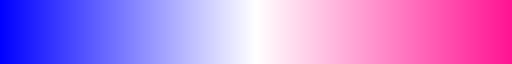

In [13]:
colors=["#0000FF","#FFFFFF","#FF1493"]
cmap_navy_pink=mcolors.LinearSegmentedColormap.from_list("blue_white_pink",colors)
cmap_navy_pink

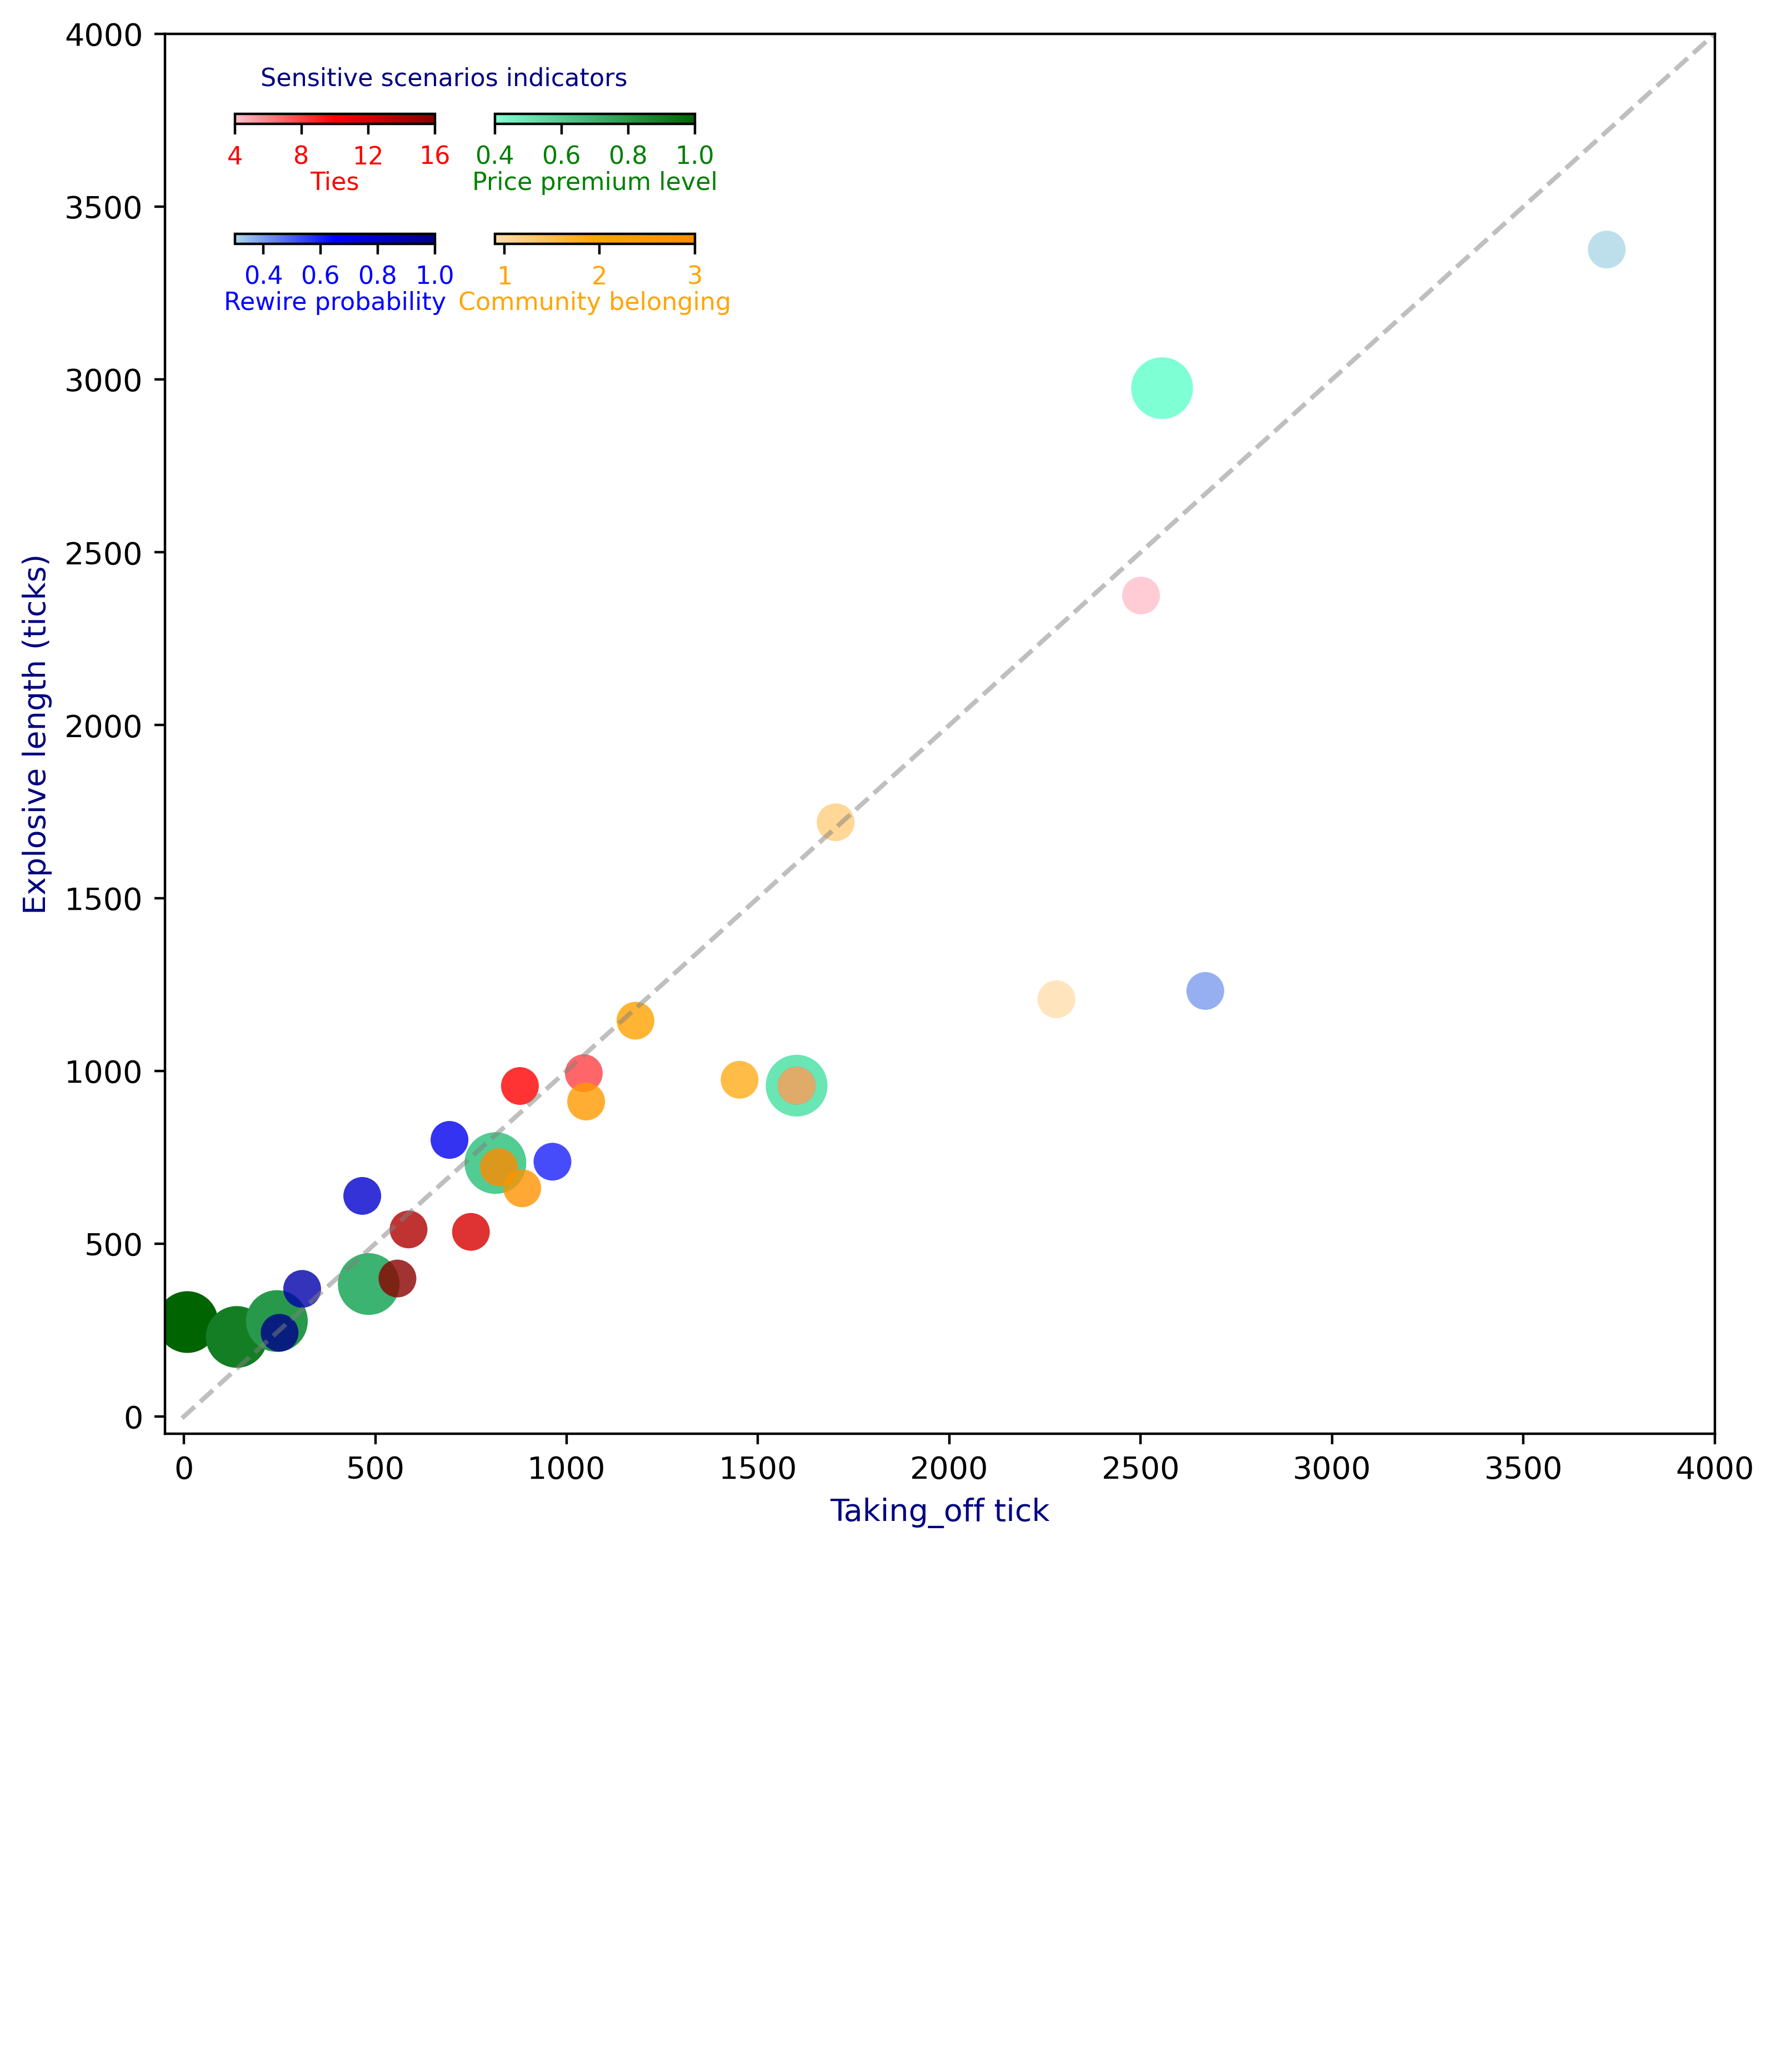

In [101]:
x_scatter_price = Diffusion_attributes_price['Take_off_tick']
y_scatter_price = Diffusion_attributes_price['Explosive_length']
x_scatter_ties = Diffusion_attributes_ties['Take_off_tick']
y_scatter_ties = Diffusion_attributes_ties['Explosive_length']
x_scatter_rewire = Diffusion_attributes_rewire['Take_off_tick']
y_scatter_rewire = Diffusion_attributes_rewire['Explosive_length']
x_scatter_belonging = Diffusion_attributes_belonging['Take_off_tick']
y_scatter_belonging = Diffusion_attributes_belonging['Explosive_length']
fig, (ax1, ax2) = plt.subplots(2, figsize=(9,18),dpi=400)

cmap_price=mcolors.LinearSegmentedColormap.from_list('my_gradient',['aquamarine','mediumseagreen','darkgreen'])
cmap_ties=mcolors.LinearSegmentedColormap.from_list('my_gradient',['pink','red','darkred'])
cmap_interaction=mcolors.LinearSegmentedColormap.from_list('my_gradient',['lightblue','blue','darkblue'])
cmap_belonging=mcolors.LinearSegmentedColormap.from_list('my_gradient',['navajowhite','orange','darkorange'])

fig_scatter=ax1.scatter(x_scatter_price,y_scatter_price,c=Diffusion_attributes_price['Price_increasement'], cmap=cmap_price,s=400, alpha=1, edgecolors='none')
fig_scatter=ax1.scatter(x_scatter_ties,y_scatter_ties,c=Diffusion_attributes_ties['Average_ties'], cmap=cmap_ties,s=150, alpha=0.8, edgecolors='none')
fig_scatter=ax1.scatter(x_scatter_rewire,y_scatter_rewire,c=Diffusion_attributes_rewire['Rewire_probability'], cmap=cmap_interaction,s=150, alpha=0.8, edgecolors='none')
fig_scatter=ax1.scatter(x_scatter_belonging,y_scatter_belonging,c=Diffusion_attributes_belonging['Community_belonging'], cmap=cmap_belonging,s=150, alpha=0.8, edgecolors='none')
#cmap_ties = 'Reds'
norm_ties = mcolors.Normalize(4,16)

ax1.plot([-5,4000],[-5,4000],color='grey',alpha=0.5,linestyle='--')

#cmap_interaction = 'Blues'
norm_interaction = mcolors.Normalize(0.3,max(Diffusion_attributes['Rewire_probability']))


#cmap_price = 'Greens'
norm_price = mcolors.Normalize(min(Diffusion_attributes['Price_increasement']),max(Diffusion_attributes['Price_increasement']))

    
#cmap_belonging = 'Oranges'
norm_belonging = mcolors.Normalize(0.9,3)


sm_ties = ScalarMappable(cmap=cmap_ties, norm=norm_ties)
sm_ties.set_array([])
colorbar_ties=fig.colorbar(sm_ties, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_ties.ax.set_position([0.16,0.76,0.1,0.1])
colorbar_ties.ax.set_xticks([4,8,12,16])
colorbar_ties.ax.set_xticklabels(colorbar_ties.get_ticks(), fontsize=8, color='red')
colorbar_ties.set_label('Ties', rotation=-360, labelpad=0.5,fontsize=8, color='red')

sm_interaction = ScalarMappable(cmap=cmap_interaction, norm=norm_interaction)
sm_interaction.set_array([])
colorbar_interaction=fig.colorbar(sm_interaction, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_interaction.ax.set_position([0.16,0.73,0.1,0.1])
colorbar_interaction.ax.set_xticks([0.4,0.6,0.8,1])
colorbar_interaction.ax.set_xticklabels(colorbar_interaction.get_ticks(), fontsize=8, color='blue')
colorbar_interaction.set_label('Rewire probability', rotation=0, labelpad=0.5,fontsize=8, color='blue')


sm_price = ScalarMappable(cmap=cmap_price, norm=norm_price)
sm_price.set_array([])
colorbar_price=fig.colorbar(sm_price, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_price.ax.set_position([0.29,0.76,0.1,0.1])
colorbar_price.ax.set_xticks([0.4,0.6,0.8,1])
colorbar_price.ax.set_xticklabels(colorbar_price.get_ticks(), fontsize=8, color='green')
colorbar_price.set_label('Price premium level', rotation=0, labelpad=0.5,fontsize=8, color='green')

sm_belonging = ScalarMappable(cmap=cmap_belonging, norm=norm_belonging)
sm_belonging.set_array([])
colorbar_belonging=fig.colorbar(sm_belonging, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_belonging.ax.set_position([0.29,0.73,0.1,0.1])
colorbar_belonging.ax.set_xticks([1,2,3])
colorbar_belonging.ax.set_xticklabels(colorbar_belonging.get_ticks(), fontsize=8, color='orange')
colorbar_belonging.set_label('Community belonging', rotation=0, labelpad=0.5,fontsize=8, color='orange')

ax2.axis('off')
ax1.text(200, 3850, 'Sensitive scenarios indicators', fontsize=8, color='navy')

ax1.set_xlabel('Taking_off tick', color='navy')
ax1.set_ylabel('Explosive length (ticks)', color='navy')
ax1.set_ylim(-50,4000)
ax1.set_xlim(-50,4000)

plt.savefig('Taking_off and explosive scatter.jpg')
plt.show()


In [45]:
Diffusion_attributes_price

,Average_ties,Rewire_probability,Price_increasement,Community_belonging,Take_off_tick,Take_off_proportion,Diffusion_completed_tick,Explosive_length,min_probability,max_probability
18,6,0.5,1.0,1.5,9,5.80,282,273,32.327754,97.816096
17,6,0.5,0.9,1.5,138,25.97,368,230,19.820518,95.863895
16,6,0.5,0.8,1.5,243,31.21,519,276,11.341232,92.303916
15,6,0.5,0.7,1.5,483,40.30,866,383,6.208529,86.123374
14,6,0.5,0.6,1.5,814,29.76,1547,733,3.311959,75.818418
13,6,0.5,0.5,1.5,1601,37.40,2558,957,1.741680,61.868017
12,6,0.5,0.4,1.5,2556,24.54,5531,2975,0.908909,45.639853


In [51]:
Diffusion_attributes_rewire

,Average_ties,Rewire_probability,Price_increasement,Community_belonging,Take_off_tick,Take_off_proportion,Diffusion_completed_tick,Explosive_length,min_probability,max_probability
11,6,1.0,0.5,1.5,250,39.00,492,242,12.496283,93.050515
10,6,0.9,0.5,1.5,309,26.22,678,369,8.599476,89.596277
9,6,0.8,0.5,1.5,466,30.72,1104,638,5.836782,85.319400
8,6,0.7,0.5,1.5,694,33.90,1494,800,3.923540,78.894036
7,6,0.6,0.5,1.5,963,28.58,1700,737,2.619991,71.611570
13,6,0.5,0.5,1.5,1601,37.40,2558,957,1.741680,61.868017
5,6,0.4,0.5,1.5,2669,42.97,3900,1231,1.154318,52.265323
6,6,0.3,0.5,1.5,3718,38.70,7094,3376,0.763499,41.906204


In [47]:
Diffusion_attributes_ties

,Average_ties,Rewire_probability,Price_increasement,Community_belonging,Take_off_tick,Take_off_proportion,Diffusion_completed_tick,Explosive_length,min_probability,max_probability
0,16,0.5,0.5,1.5,558,40.61,957,399,1.74168,62.433165
1,14,0.5,0.5,1.5,587,33.88,1128,541,1.74168,62.433165
2,12,0.5,0.5,1.5,750,37.34,1284,534,1.74168,62.433165
3,10,0.5,0.5,1.5,878,33.00,1834,956,1.74168,62.433165
4,8,0.5,0.5,1.5,1045,25.65,2038,993,1.74168,62.433165
13,6,0.5,0.5,1.5,1601,37.40,2558,957,1.74168,61.868017
31,4,0.5,0.5,1.5,2501,30.58,4876,2375,1.74168,62.433165


In [49]:
Diffusion_attributes_belonging

,Average_ties,Rewire_probability,Price_increasement,Community_belonging,Take_off_tick,Take_off_proportion,Diffusion_completed_tick,Explosive_length,min_probability,max_probability
25,6,0.5,0.5,3.0,823,38.38,1544,721,3.498413,77.267451
24,6,0.5,0.5,2.7,884,36.31,1544,660,3.046169,74.656494
23,6,0.5,0.5,2.4,1051,34.41,1962,911,2.650782,71.854889
22,6,0.5,0.5,2.1,1180,39.23,2325,1145,2.305495,68.872708
21,6,0.5,0.5,1.8,1452,45.71,2426,974,2.004258,65.725267
13,6,0.5,0.5,1.5,1601,37.40,2558,957,1.741680,61.868017
20,6,0.5,0.5,1.2,1703,31.42,3422,1719,1.512970,59.022002
19,6,0.5,0.5,0.9,2280,45.51,3487,1207,1.313893,55.521762


In [73]:
Diffusion_attributes_price1=Diffusion_attributes_price.iloc[[0,1,2,3,4,5,6]]
Diffusion_attributes_rewire1=Diffusion_attributes_rewire.iloc[[0,1,2,3,4,5,6]]
Diffusion_attributes_ties1=Diffusion_attributes_ties.iloc[[0,1,2,3,4,5,6]]
Diffusion_attributes_belonging1=Diffusion_attributes_belonging.iloc[[0,1,2,3,4,5]]

In [75]:
Diffusion_attributes_belonging1

,Average_ties,Rewire_probability,Price_increasement,Community_belonging,Take_off_tick,Take_off_proportion,Diffusion_completed_tick,Explosive_length,min_probability,max_probability
25,6,0.5,0.5,3.0,823,38.38,1544,721,3.498413,77.267451
24,6,0.5,0.5,2.7,884,36.31,1544,660,3.046169,74.656494
23,6,0.5,0.5,2.4,1051,34.41,1962,911,2.650782,71.854889
22,6,0.5,0.5,2.1,1180,39.23,2325,1145,2.305495,68.872708
21,6,0.5,0.5,1.8,1452,45.71,2426,974,2.004258,65.725267
13,6,0.5,0.5,1.5,1601,37.40,2558,957,1.741680,61.868017


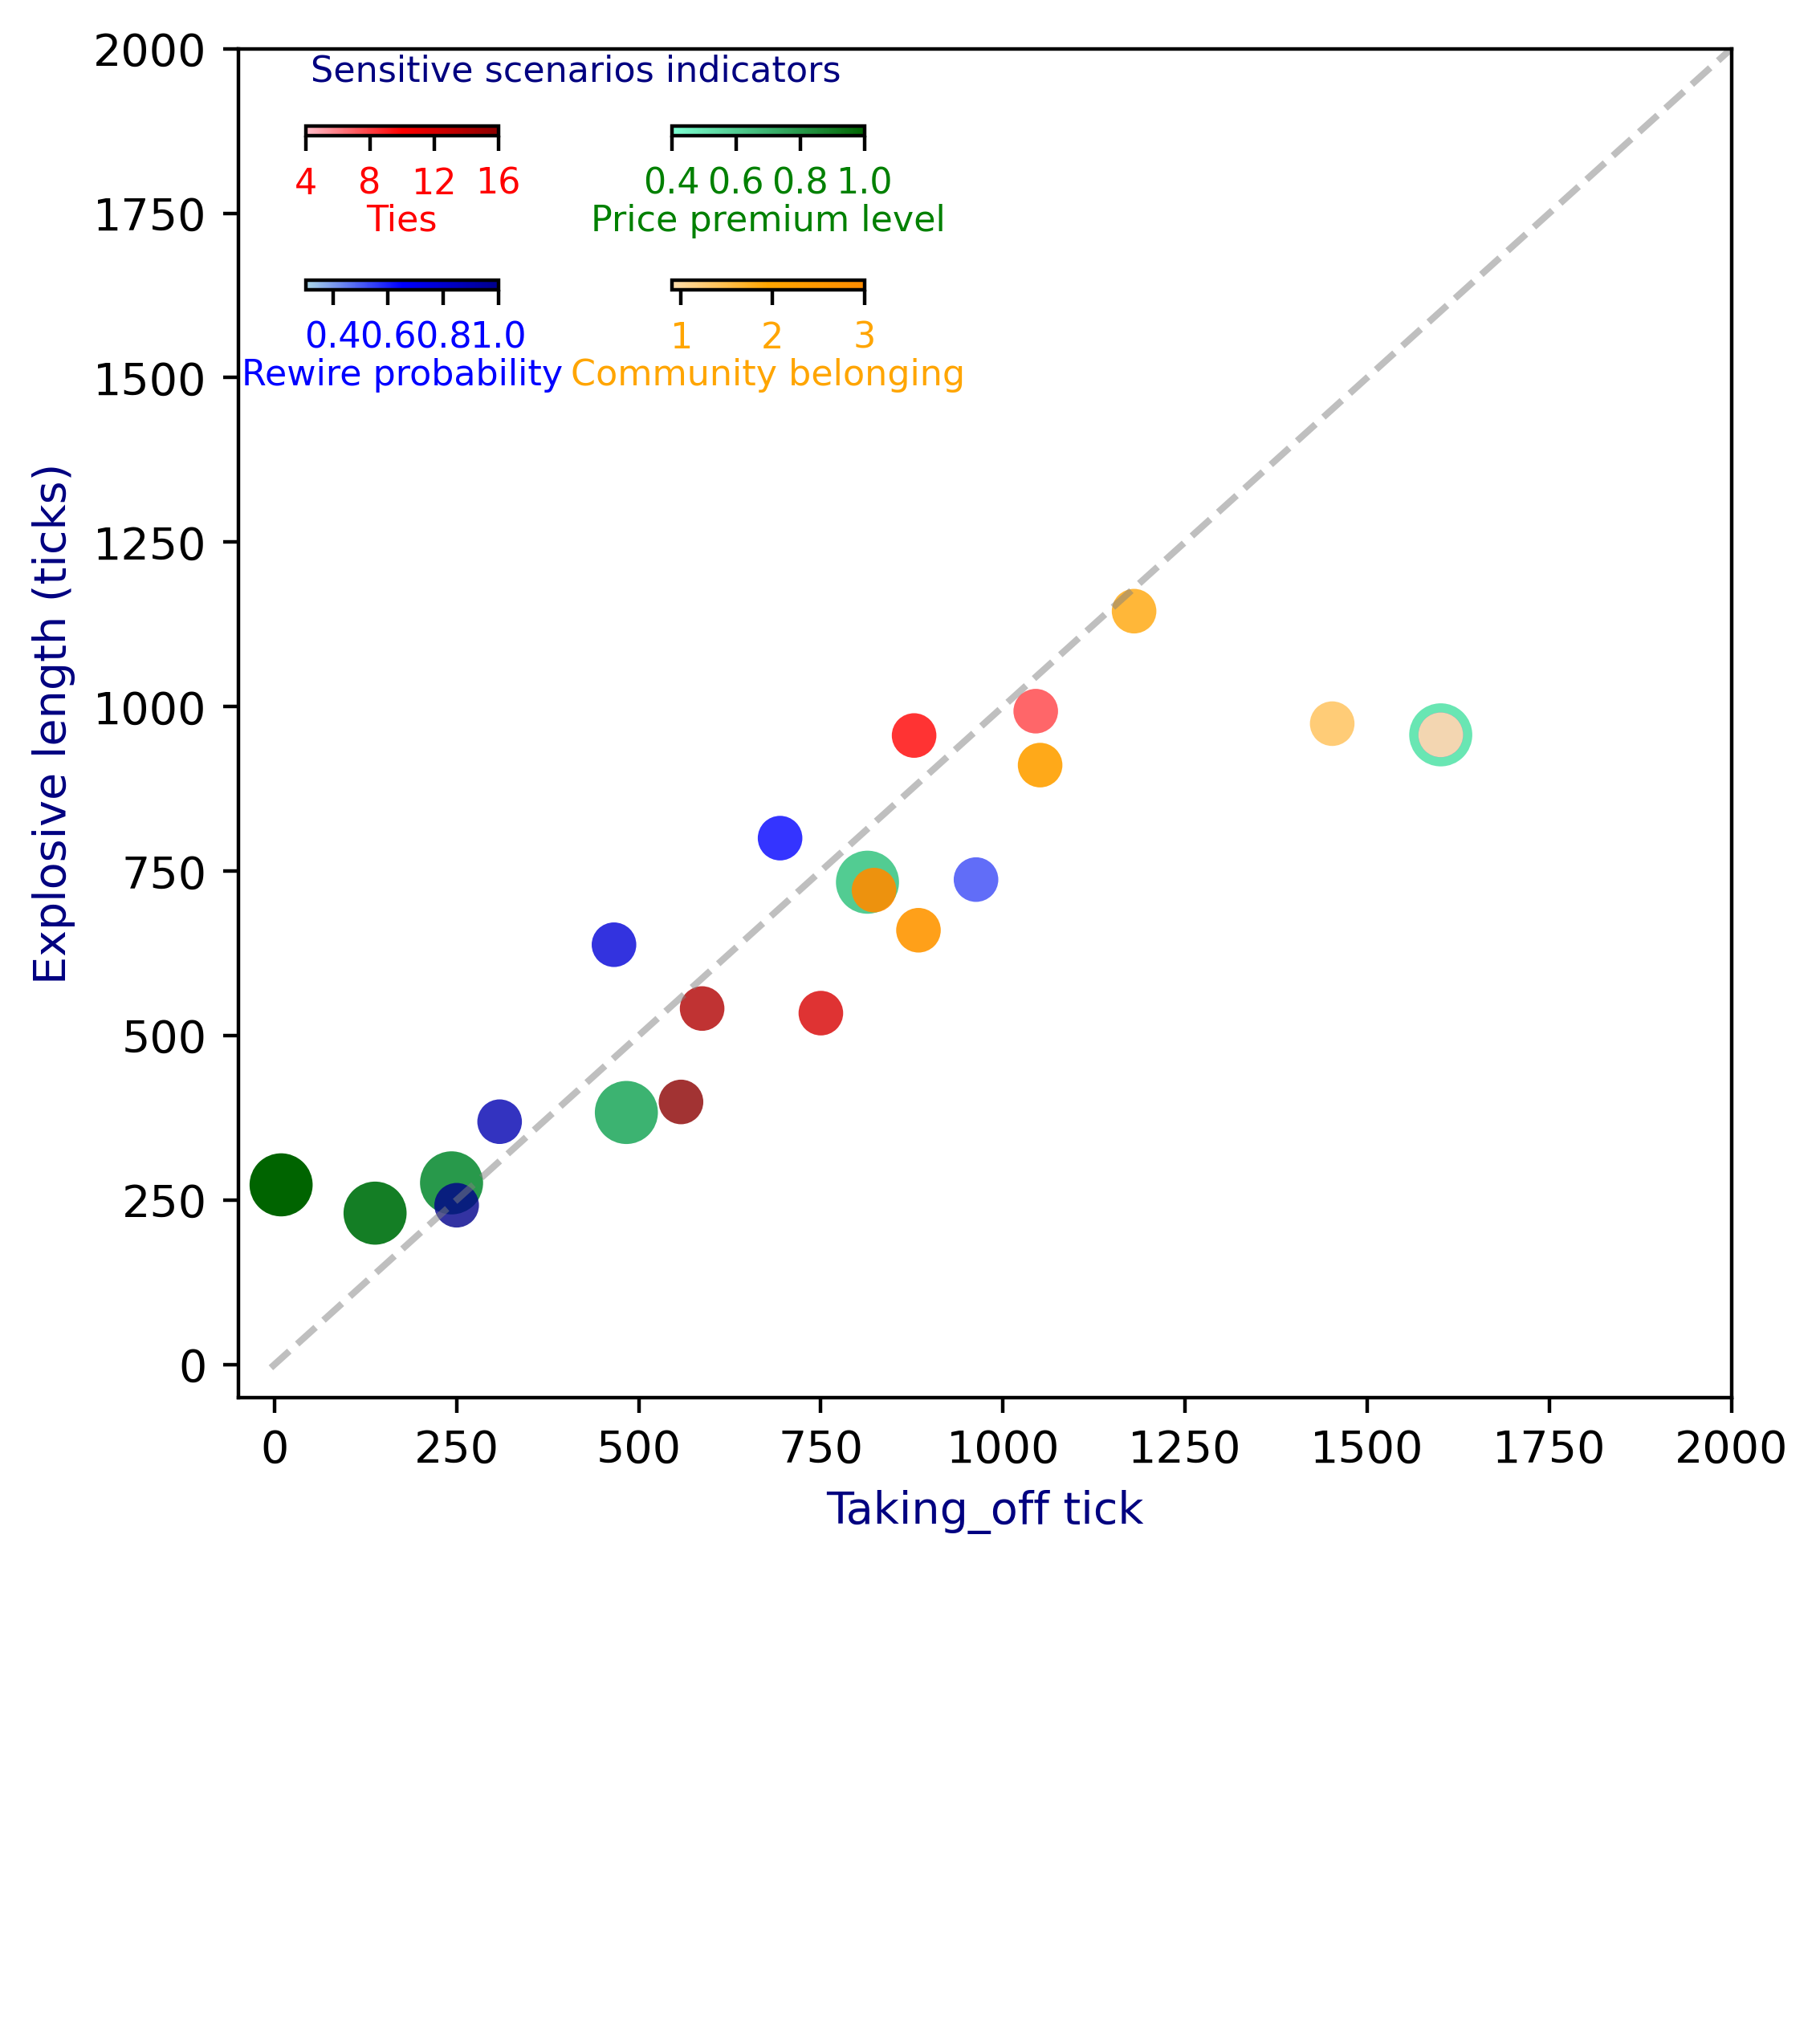

In [81]:
x_scatter_price = Diffusion_attributes_price1['Take_off_tick']
y_scatter_price = Diffusion_attributes_price1['Explosive_length']
x_scatter_ties = Diffusion_attributes_ties1['Take_off_tick']
y_scatter_ties = Diffusion_attributes_ties1['Explosive_length']
x_scatter_rewire = Diffusion_attributes_rewire1['Take_off_tick']
y_scatter_rewire = Diffusion_attributes_rewire1['Explosive_length']
x_scatter_belonging = Diffusion_attributes_belonging1['Take_off_tick']
y_scatter_belonging = Diffusion_attributes_belonging1['Explosive_length']
fig, (ax1, ax2) = plt.subplots(2, figsize=(6,12),dpi=400)

cmap_price=mcolors.LinearSegmentedColormap.from_list('my_gradient',['aquamarine','mediumseagreen','darkgreen'])
cmap_ties=mcolors.LinearSegmentedColormap.from_list('my_gradient',['pink','red','darkred'])
cmap_interaction=mcolors.LinearSegmentedColormap.from_list('my_gradient',['lightblue','blue','darkblue'])
cmap_belonging=mcolors.LinearSegmentedColormap.from_list('my_gradient',['navajowhite','orange','darkorange'])

fig_scatter=ax1.scatter(x_scatter_price,y_scatter_price,c=Diffusion_attributes_price1['Price_increasement'], cmap=cmap_price,s=200, alpha=1, edgecolors='none')
fig_scatter=ax1.scatter(x_scatter_ties,y_scatter_ties,c=Diffusion_attributes_ties1['Average_ties'], cmap=cmap_ties,s=100, alpha=0.8, edgecolors='none')
fig_scatter=ax1.scatter(x_scatter_rewire,y_scatter_rewire,c=Diffusion_attributes_rewire1['Rewire_probability'], cmap=cmap_interaction,s=100, alpha=0.8, edgecolors='none')
fig_scatter=ax1.scatter(x_scatter_belonging,y_scatter_belonging,c=Diffusion_attributes_belonging1['Community_belonging'], cmap=cmap_belonging,s=100, alpha=0.9, edgecolors='none')
#cmap_ties = 'Reds'
norm_ties = mcolors.Normalize(4,16)

ax1.plot([-5,2000],[-5,2000],color='grey',alpha=0.5,linestyle='--')

#cmap_interaction = 'Blues'
norm_interaction = mcolors.Normalize(0.3,max(Diffusion_attributes['Rewire_probability']))


#cmap_price = 'Greens'
norm_price = mcolors.Normalize(min(Diffusion_attributes['Price_increasement']),max(Diffusion_attributes['Price_increasement']))

    
#cmap_belonging = 'Oranges'
norm_belonging = mcolors.Normalize(0.9,3)


sm_ties = ScalarMappable(cmap=cmap_ties, norm=norm_ties)
sm_ties.set_array([])
colorbar_ties=fig.colorbar(sm_ties, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_ties.ax.set_position([0.16,0.76,0.1,0.1])
colorbar_ties.ax.set_xticks([4,8,12,16])
colorbar_ties.ax.set_xticklabels(colorbar_ties.get_ticks(), fontsize=8, color='red')
colorbar_ties.set_label('Ties', rotation=-360, labelpad=0.5,fontsize=8, color='red')

sm_interaction = ScalarMappable(cmap=cmap_interaction, norm=norm_interaction)
sm_interaction.set_array([])
colorbar_interaction=fig.colorbar(sm_interaction, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_interaction.ax.set_position([0.16,0.72,0.1,0.1])
colorbar_interaction.ax.set_xticks([0.4,0.6,0.8,1])
colorbar_interaction.ax.set_xticklabels(colorbar_interaction.get_ticks(), fontsize=8, color='blue')
colorbar_interaction.set_label('Rewire probability', rotation=0, labelpad=0.5,fontsize=8, color='blue')


sm_price = ScalarMappable(cmap=cmap_price, norm=norm_price)
sm_price.set_array([])
colorbar_price=fig.colorbar(sm_price, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_price.ax.set_position([0.35,0.76,0.1,0.1])
colorbar_price.ax.set_xticks([0.4,0.6,0.8,1])
colorbar_price.ax.set_xticklabels(colorbar_price.get_ticks(), fontsize=8, color='green')
colorbar_price.set_label('Price premium level', rotation=0, labelpad=0.5,fontsize=8, color='green')

sm_belonging = ScalarMappable(cmap=cmap_belonging, norm=norm_belonging)
sm_belonging.set_array([])
colorbar_belonging=fig.colorbar(sm_belonging, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_belonging.ax.set_position([0.35,0.72,0.1,0.1])
colorbar_belonging.ax.set_xticks([1,2,3])
colorbar_belonging.ax.set_xticklabels(colorbar_belonging.get_ticks(), fontsize=8, color='orange')
colorbar_belonging.set_label('Community belonging', rotation=0, labelpad=0.5,fontsize=8, color='orange')

ax2.axis('off')
ax1.text(50, 1950, 'Sensitive scenarios indicators', fontsize=8, color='navy')

ax1.set_xlabel('Taking_off tick', color='navy')
ax1.set_ylabel('Explosive length (ticks)', color='navy')
ax1.set_ylim(-50,2000)
ax1.set_xlim(-50,2000)

plt.savefig('Taking_off and explosive scatter above.jpg')
plt.show()


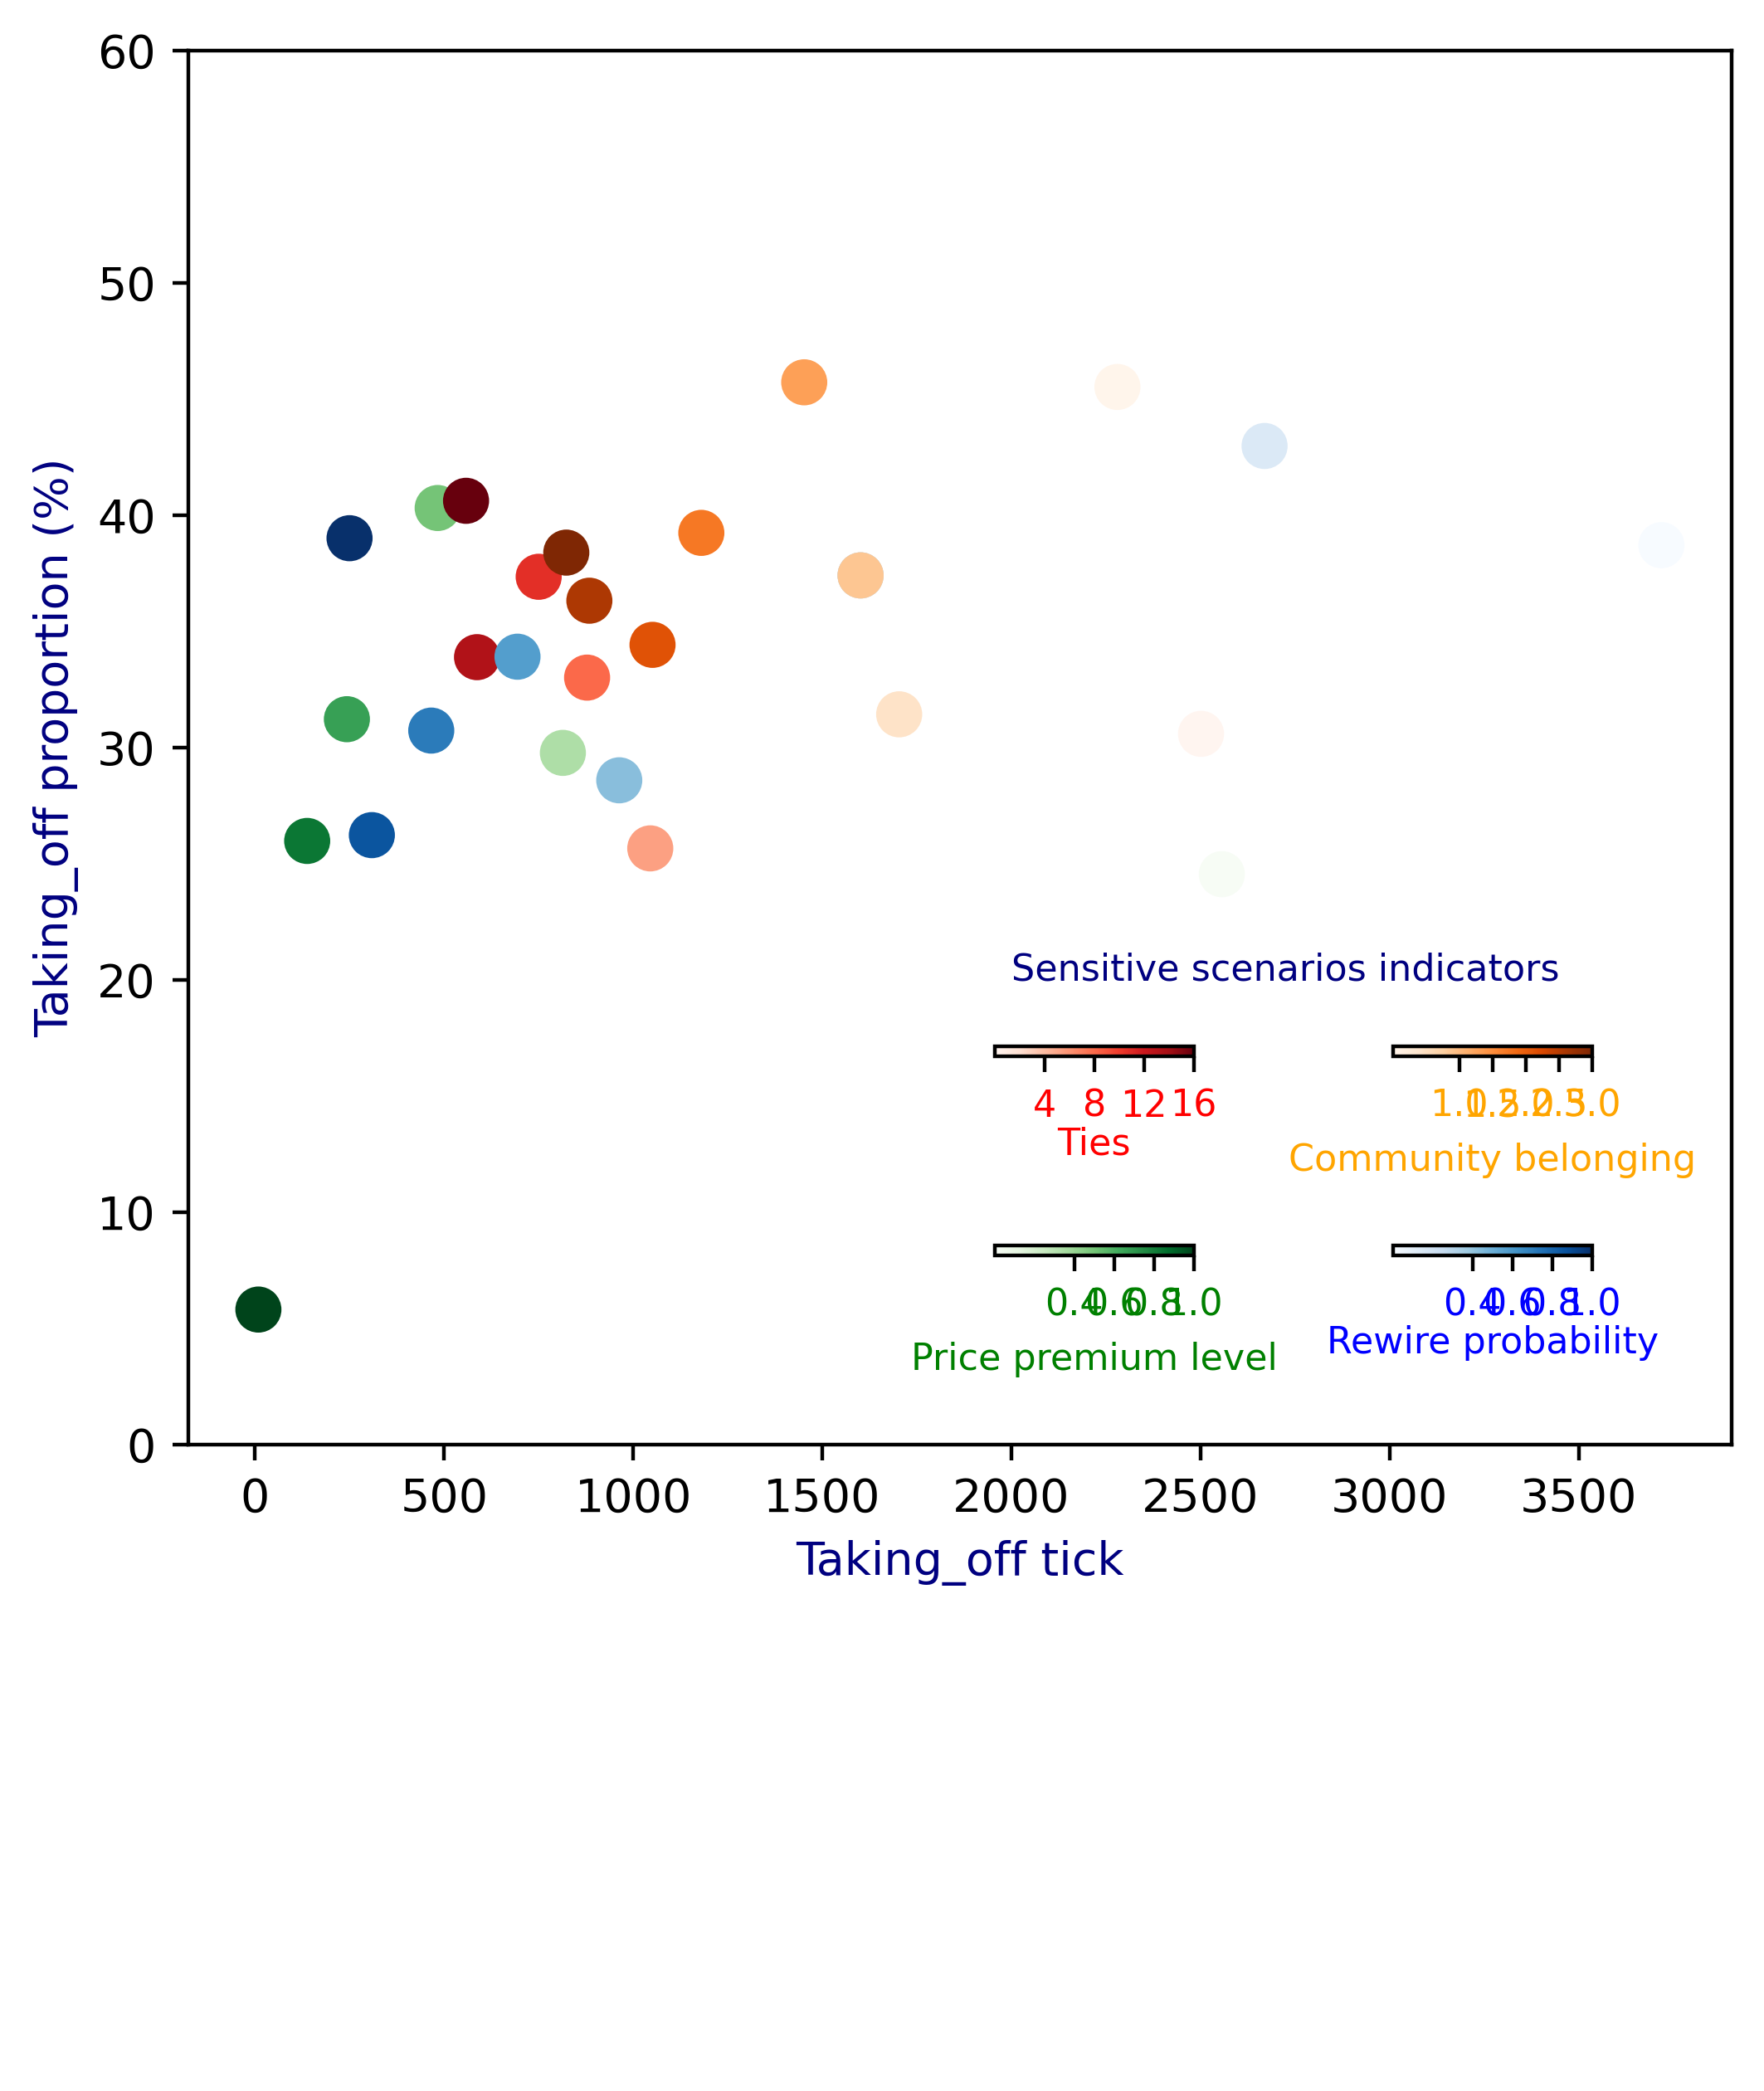

In [25]:
x_scatter_price = Diffusion_attributes_price['Take_off_tick']
y_scatter_price = Diffusion_attributes_price['Take_off_proportion']
x_scatter_ties = Diffusion_attributes_ties['Take_off_tick']
y_scatter_ties = Diffusion_attributes_ties['Take_off_proportion']
x_scatter_rewire = Diffusion_attributes_rewire['Take_off_tick']
y_scatter_rewire = Diffusion_attributes_rewire['Take_off_proportion']
x_scatter_belonging = Diffusion_attributes_belonging['Take_off_tick']
y_scatter_belonging = Diffusion_attributes_belonging['Take_off_proportion']
fig, (ax1, ax2) = plt.subplots(2, figsize=(6,12),dpi=400)

fig_scatter=ax1.scatter(x_scatter_price,y_scatter_price,c=Diffusion_attributes_price['Price_increasement'], cmap='Greens',s=100, alpha=1, edgecolors='none')
fig_scatter=ax1.scatter(x_scatter_ties,y_scatter_ties,c=Diffusion_attributes_ties['Average_ties'], cmap='Reds',s=100, alpha=1, edgecolors='none')
fig_scatter=ax1.scatter(x_scatter_rewire,y_scatter_rewire,c=Diffusion_attributes_rewire['Rewire_probability'], cmap='Blues',s=100, alpha=1, edgecolors='none')
fig_scatter=ax1.scatter(x_scatter_belonging,y_scatter_belonging,c=Diffusion_attributes_belonging['Community_belonging'], cmap='Oranges',s=100, alpha=1, edgecolors='none')

cmap_ties = 'Reds'
norm_ties = mcolors.Normalize(0,16)


cmap_interaction = 'Blues'
norm_interaction = mcolors.Normalize(0,max(Diffusion_attributes['Rewire_probability']))


cmap_price = 'Greens'
norm_price = mcolors.Normalize(0,max(Diffusion_attributes['Price_increasement']))

    
cmap_belonging = 'Oranges'
norm_belonging = mcolors.Normalize(0,3)


sm_ties = ScalarMappable(cmap=cmap_ties, norm=norm_ties)
sm_ties.set_array([])
colorbar_ties=fig.colorbar(sm_ties, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_ties.ax.set_position([0.53,0.53,0.1,0.1])
colorbar_ties.ax.set_xticks([4,8,12,16])
colorbar_ties.ax.set_xticklabels(colorbar_ties.get_ticks(), fontsize=8, color='red')
colorbar_ties.set_label('Ties', rotation=-360, labelpad=0.55, fontsize=8, color='red')

sm_interaction = ScalarMappable(cmap=cmap_interaction, norm=norm_interaction)
sm_interaction.set_array([])
colorbar_interaction=fig.colorbar(sm_interaction, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_interaction.ax.set_position([0.73,0.48,0.1,0.1])
colorbar_interaction.ax.set_xticks([0.4,0.6,0.8,1])
colorbar_interaction.ax.set_xticklabels(colorbar_interaction.get_ticks(), fontsize=8, color='blue')
colorbar_interaction.set_label('Rewire probability', rotation=-360, labelpad=0.35, fontsize=8, color='blue')


sm_price = ScalarMappable(cmap=cmap_price, norm=norm_price)
sm_price.set_array([])
colorbar_price=fig.colorbar(sm_price, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_price.ax.set_position([0.53,0.48,0.1,0.1])
colorbar_price.ax.set_xticks([0.4,0.6,0.8,1])
colorbar_price.ax.set_xticklabels(colorbar_price.get_ticks(), fontsize=8, color='green')
colorbar_price.set_label('Price premium level', rotation=0, fontsize=8, color='green')

sm_belonging = ScalarMappable(cmap=cmap_belonging, norm=norm_belonging)
sm_belonging.set_array([])
colorbar_belonging=fig.colorbar(sm_belonging, shrink=0.3, ax=ax2, orientation='horizontal')
colorbar_belonging.ax.set_position([0.73,0.53,0.1,0.1])
colorbar_belonging.ax.set_xticks([1,1.5,2,2.5,3])
colorbar_belonging.ax.set_xticklabels(colorbar_belonging.get_ticks(), fontsize=8, color='orange')
colorbar_belonging.set_label('Community belonging', rotation=0, fontsize=8, color='orange')

ax2.axis('off')
ax1.text(2000, 20, 'Sensitive scenarios indicators', fontsize=8, color='navy')

ax1.set_xlabel('Taking_off tick', color='navy')
ax1.set_ylabel('Taking_off proportion (%)', color='navy')
ax1.set_ylim(0,60)

plt.savefig('Taking_off_explosive.jpg')
plt.show()


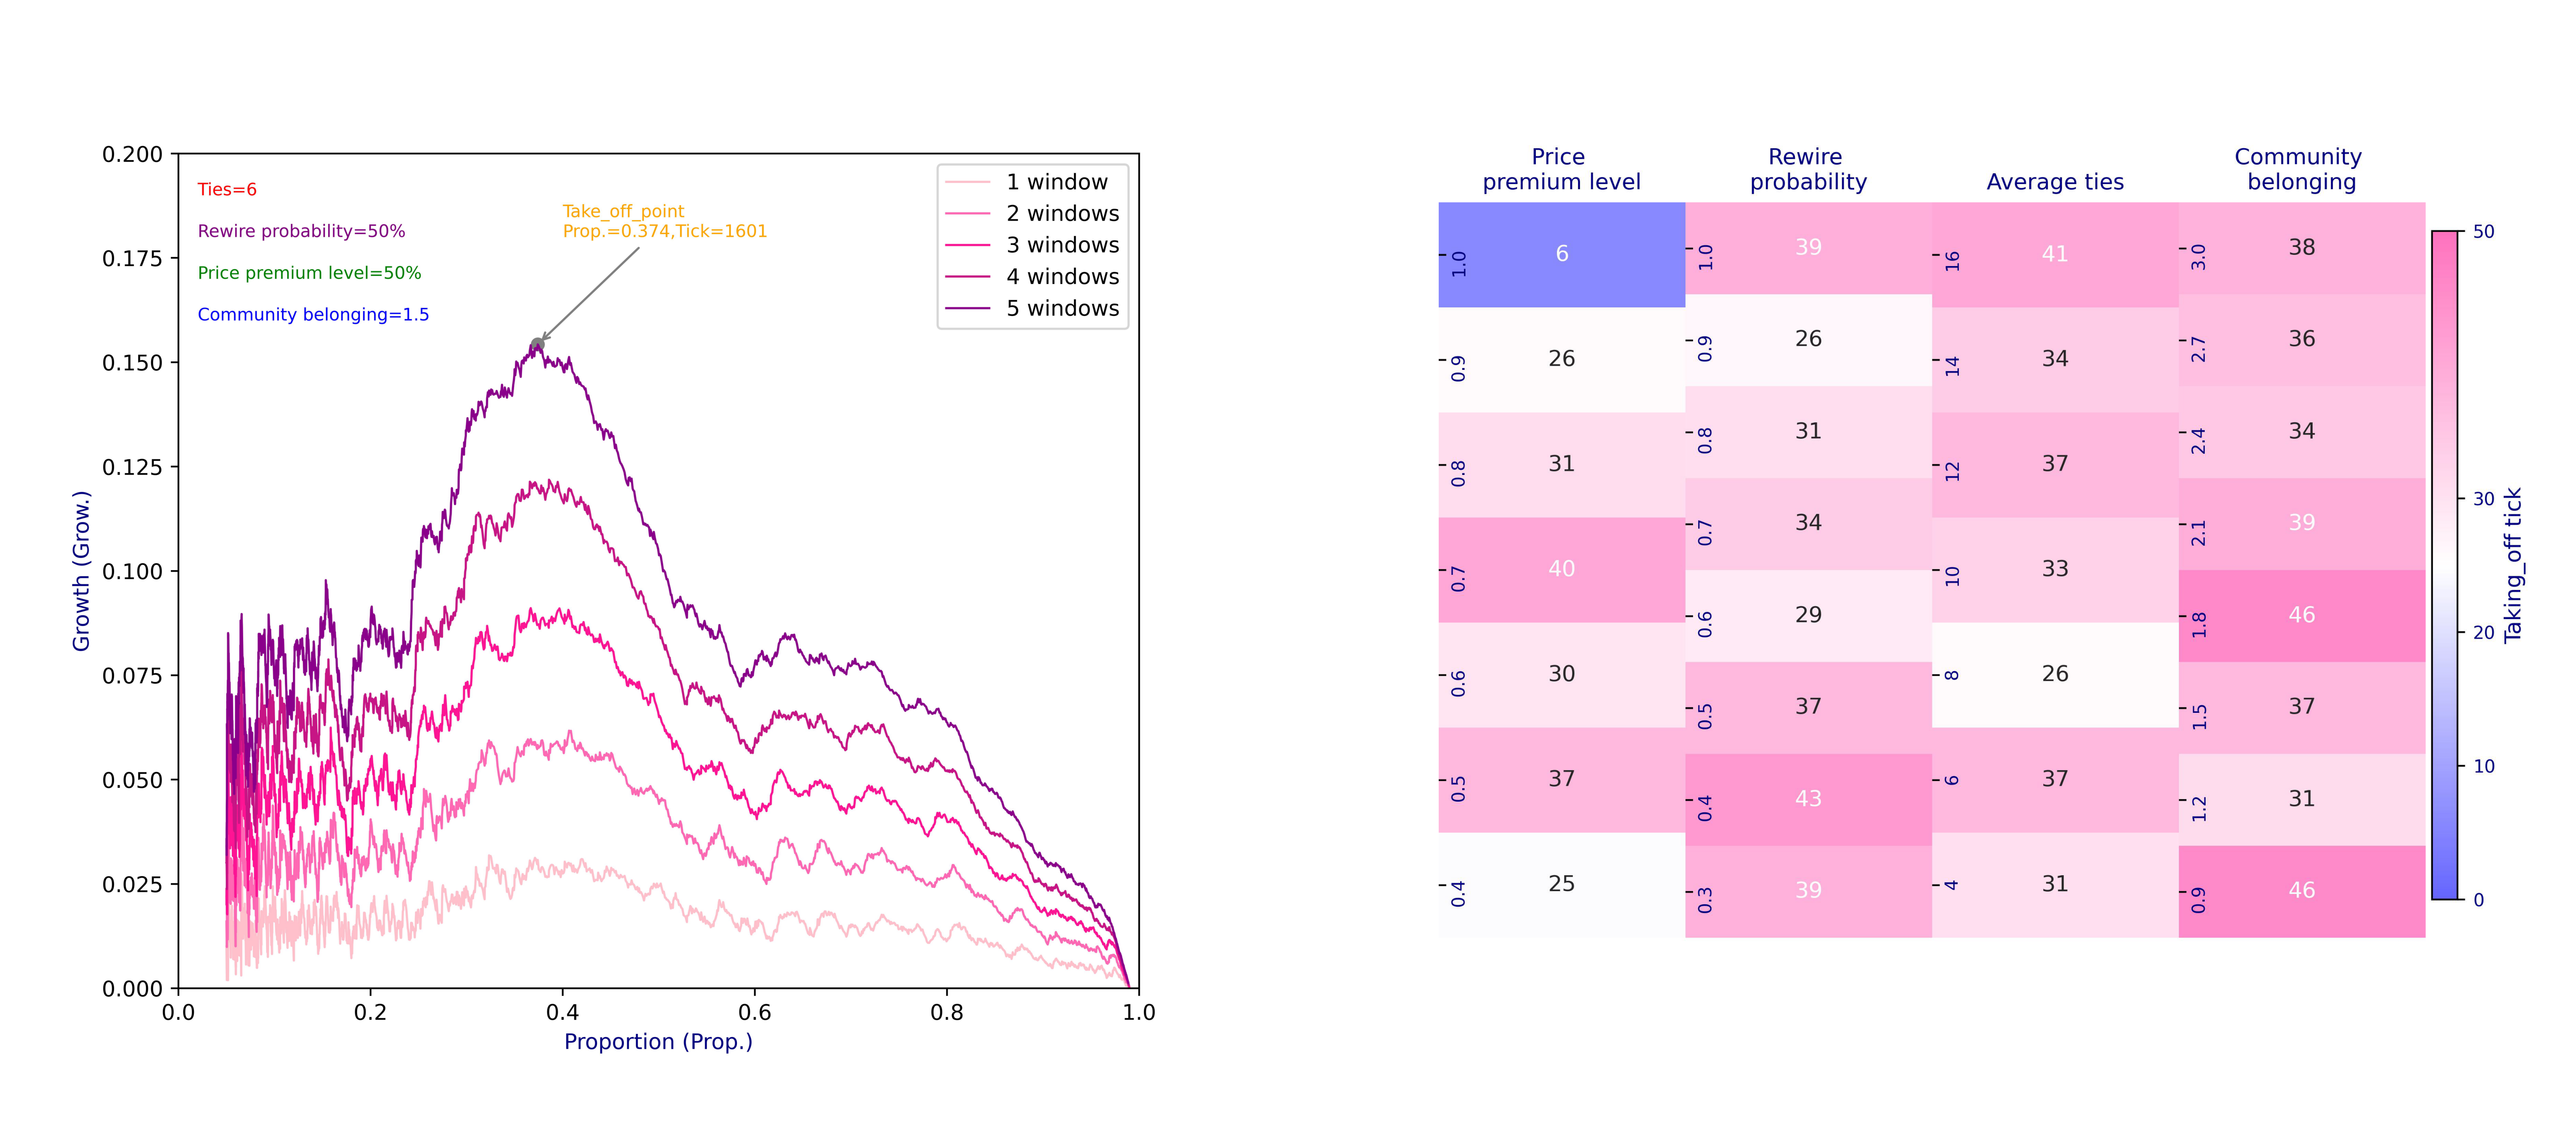

In [79]:
import matplotlib.image as mpimg

fig, ax = plt.subplots(1,2,figsize=(14, 6),dpi=500)

img2_1=mpimg.imread('Taking_off_proportion.jpg')
img1_1=mpimg.imread('finding_windows.jpg')

ax[0].imshow(img1_1)
ax[0].axis('off')
#ax[0].set_title('(a) Finding taking_off points', fontsize=12, y=0)

ax[1].imshow(img2_1)
ax[1].axis('off')
#ax[1].set_title(' \n\n\n\n(b) Distribution of taking_off points', fontsize=12, y=0)

plt.subplots_adjust(wspace=0)
plt.savefig('finding windows and distribution of taking_off points_new.jpg')
plt.show()

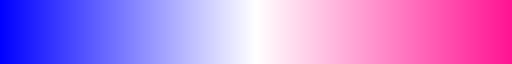

In [21]:
colors=["#0000FF","#FFFFFF","#FF1493"]
cmap_navy_pink=mcolors.LinearSegmentedColormap.from_list("blue_white_pink",colors)
cmap_navy_pink

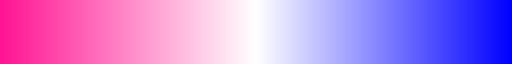

In [13]:
colors=["#FF1493","#FFFFFF","#0000FF"]
cmap_navy_pink=mcolors.LinearSegmentedColormap.from_list("pink_white_blue",colors)
cmap_navy_pink

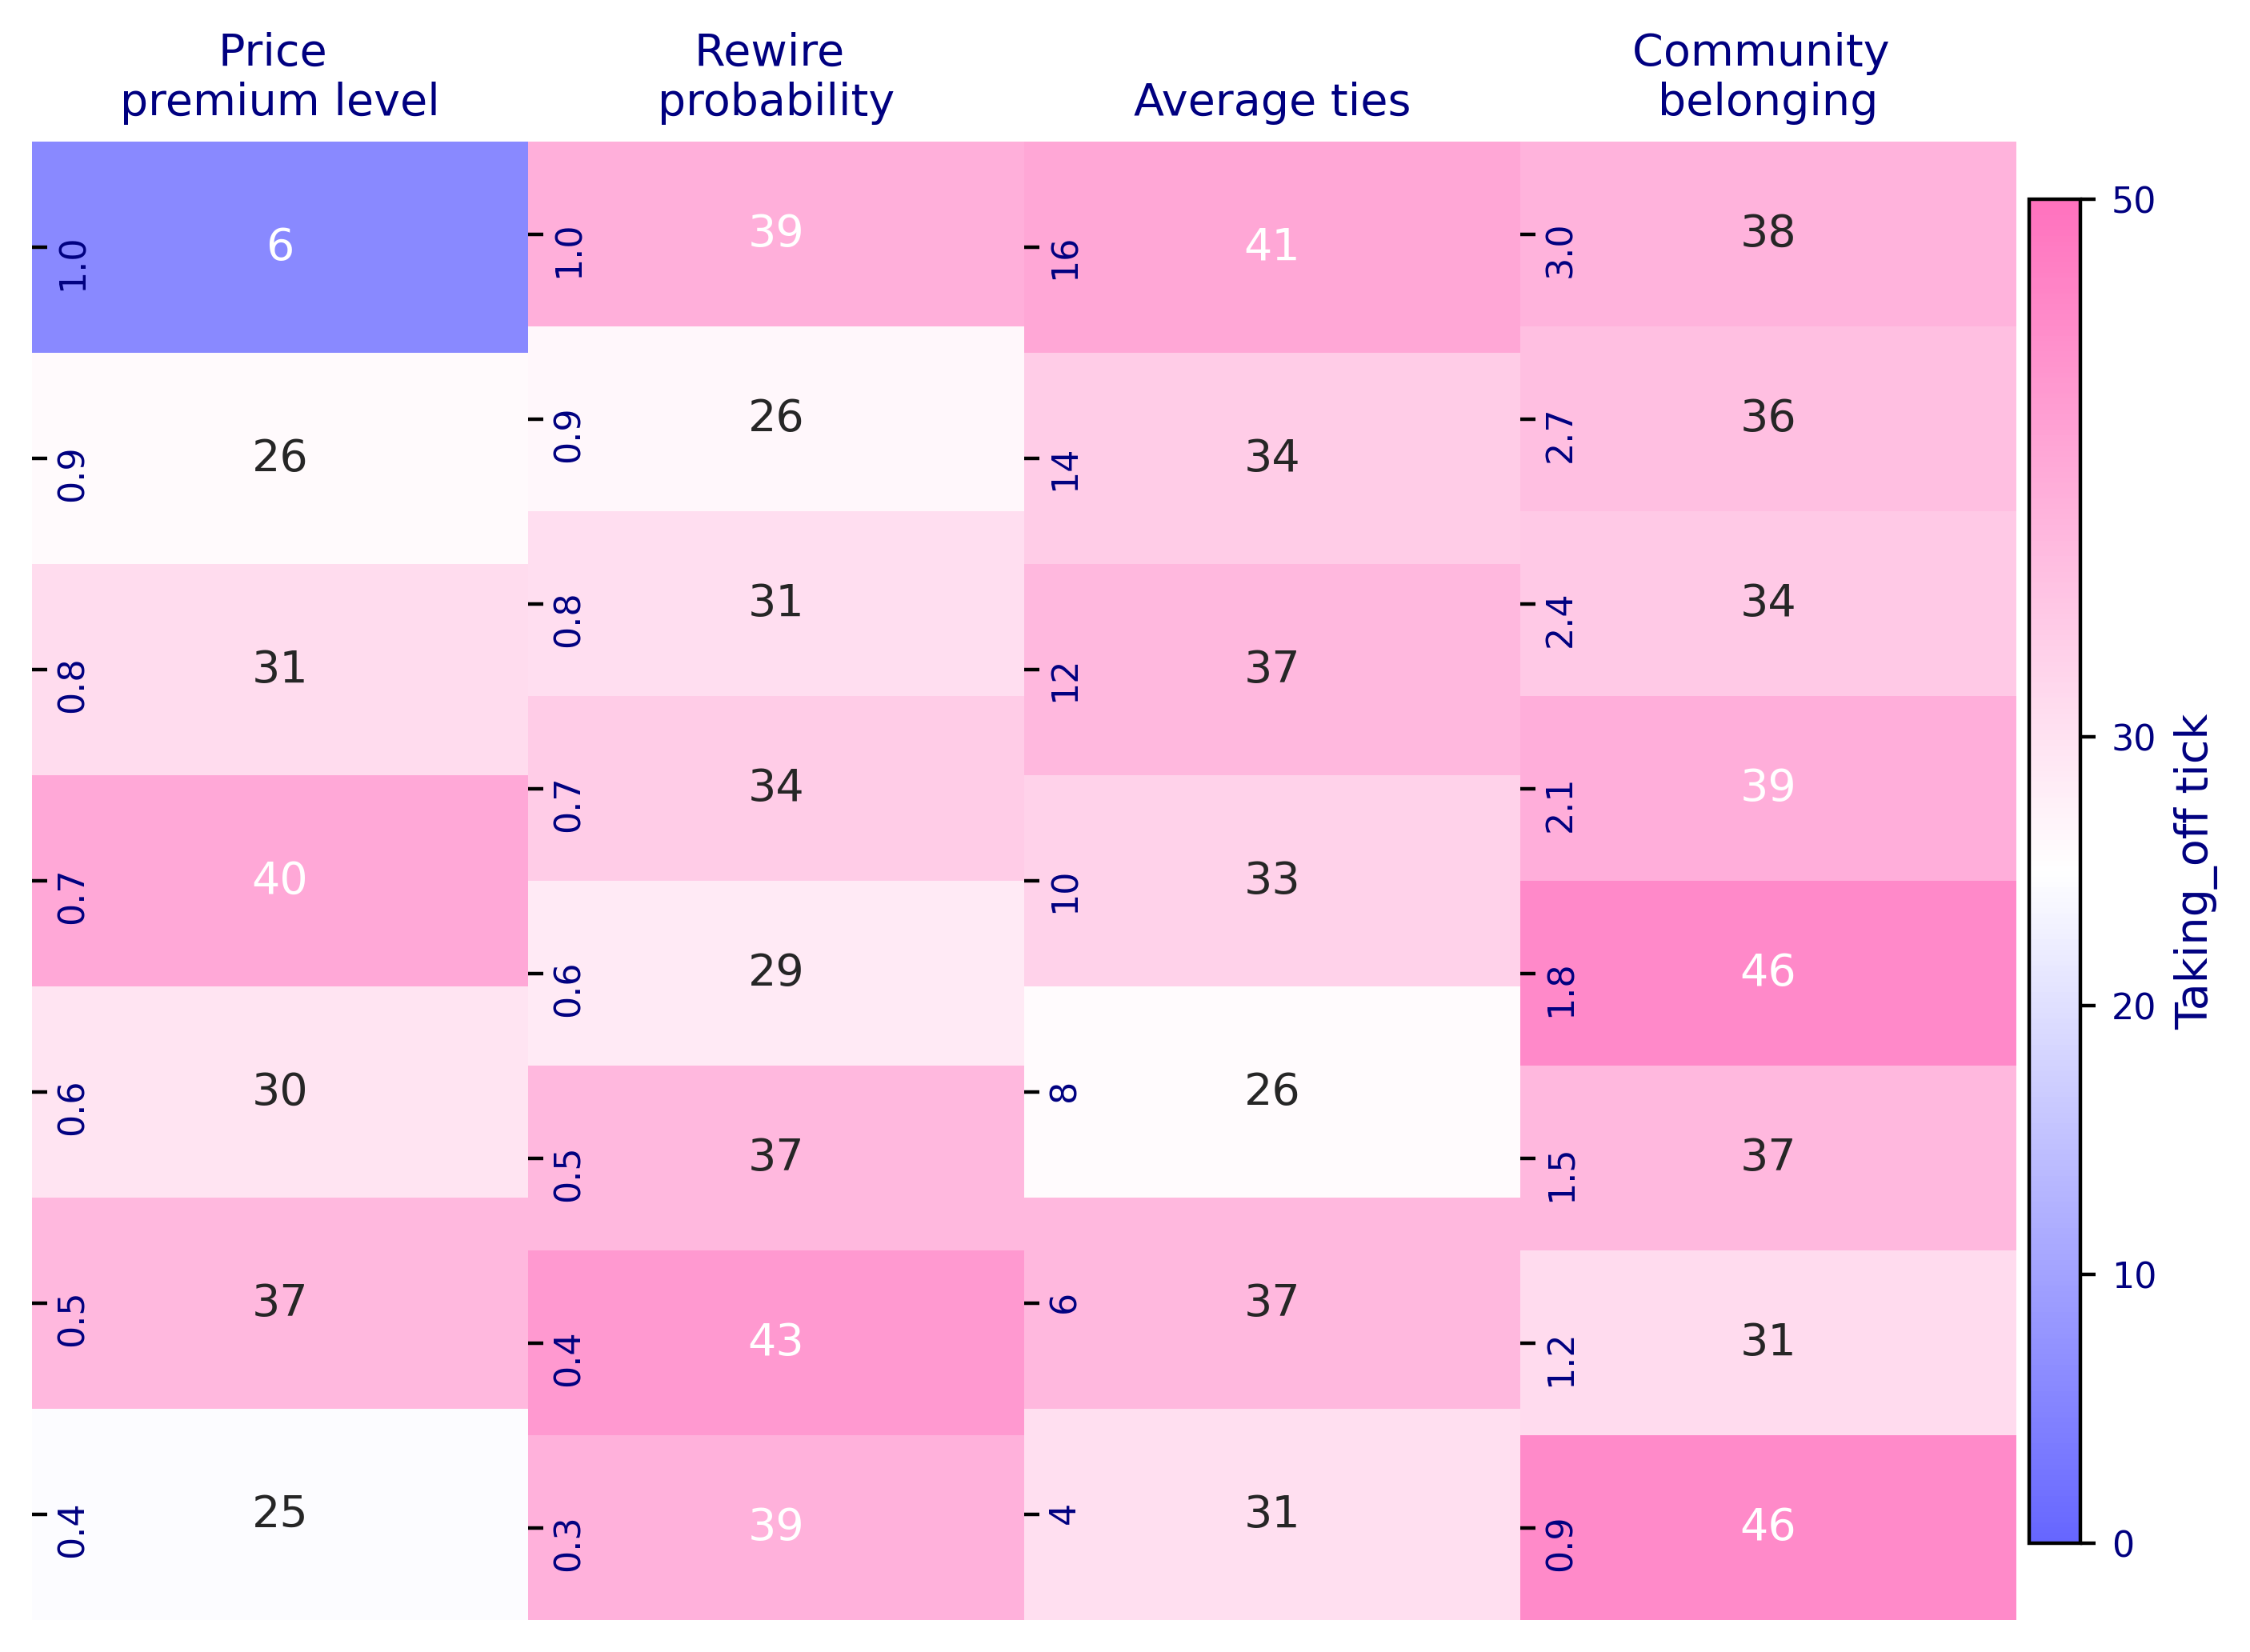

In [23]:
import seaborn as sns
price_heatmap_data1=Diffusion_attributes_price[['Price_increasement','Take_off_proportion']]
rewire_heatmap_data1=Diffusion_attributes_rewire[['Rewire_probability','Take_off_proportion']]
ties_heatmap_data1=Diffusion_attributes_ties[['Average_ties','Take_off_proportion']]
belonging_heatmap_data1=Diffusion_attributes_belonging[['Community_belonging','Take_off_proportion']]

fig,axes=plt.subplots(1,4,figsize=(8,6),dpi=400)

vmin=0
vmax=50


sns.heatmap(price_heatmap_data1.set_index('Price_increasement'),ax=axes[0],cmap=cmap_navy_pink,alpha=0.6,annot=True,fmt='.0f',cbar=False,vmin=vmin,vmax=vmax)
sns.heatmap(rewire_heatmap_data1.set_index('Rewire_probability'),ax=axes[1],cmap=cmap_navy_pink,alpha=0.6,annot=True,fmt='.0f',cbar=False,vmin=vmin,vmax=vmax)
sns.heatmap(ties_heatmap_data1.set_index('Average_ties'),ax=axes[2],cmap=cmap_navy_pink,alpha=0.6,annot=True,cbar=False,fmt='.0f',vmin=vmin,vmax=vmax)
sns.heatmap(belonging_heatmap_data1.set_index('Community_belonging'),ax=axes[3],cmap=cmap_navy_pink,alpha=0.6,annot=True,fmt='.0f',cbar=False,vmin=vmin,vmax=vmax)

axes[0].set_title('Price \npremium level',fontsize=10,color='navy')
axes[1].set_title('Rewire \nprobability',fontsize=10,color='navy')
axes[2].set_title('Average ties',fontsize=10,color='navy')
axes[3].set_title('Community \nbelonging',fontsize=10,color='navy')

axes[0].set_xticks([])
axes[1].set_xticks([])
axes[2].set_xticks([])
axes[3].set_xticks([])

#axes[0].set_yticks([])
#axes[1].set_yticks([])
#axes[2].set_yticks([])
#axes[3].set_yticks([])

axes[0].tick_params(axis='y',labelsize=8,labelcolor='navy',direction='in',pad=-13)
#axes[0].yaxis.set_ticks_position('right')
axes[1].tick_params(axis='y',labelsize=8,labelcolor='navy',direction='in',pad=-13)
#axes[1].yaxis.set_ticks_position('right')
axes[2].tick_params(axis='y',labelsize=8,labelcolor='navy',direction='in',pad=-13)
#axes[2].yaxis.set_ticks_position('right')
axes[3].tick_params(axis='y',labelsize=8,labelcolor='navy',direction='in',pad=-13)
#axes[3].yaxis.set_ticks_position('right')

axes[0].set_ylabel("")
axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[3].set_ylabel("")

sm=plt.cm.ScalarMappable(cmap=cmap_navy_pink,norm=plt.Normalize(vmin=vmin,vmax=vmax))
sm.set_array([])

cbar_ax=fig.add_axes([0.905,0.15,0.02,0.7])
cbar=plt.colorbar(sm,ax=axes,alpha=0.6,cax=cbar_ax)
cbar.set_label('Taking_off tick',fontsize=10,color='navy')
cbar.set_ticks([0,10,20,30,50])
cbar.ax.tick_params(labelsize=8,labelcolor='navy')
cbar.ax.invert_xaxis()

plt.subplots_adjust(wspace=0.0)
plt.savefig('Taking_off_proportion.jpg')
plt.show()

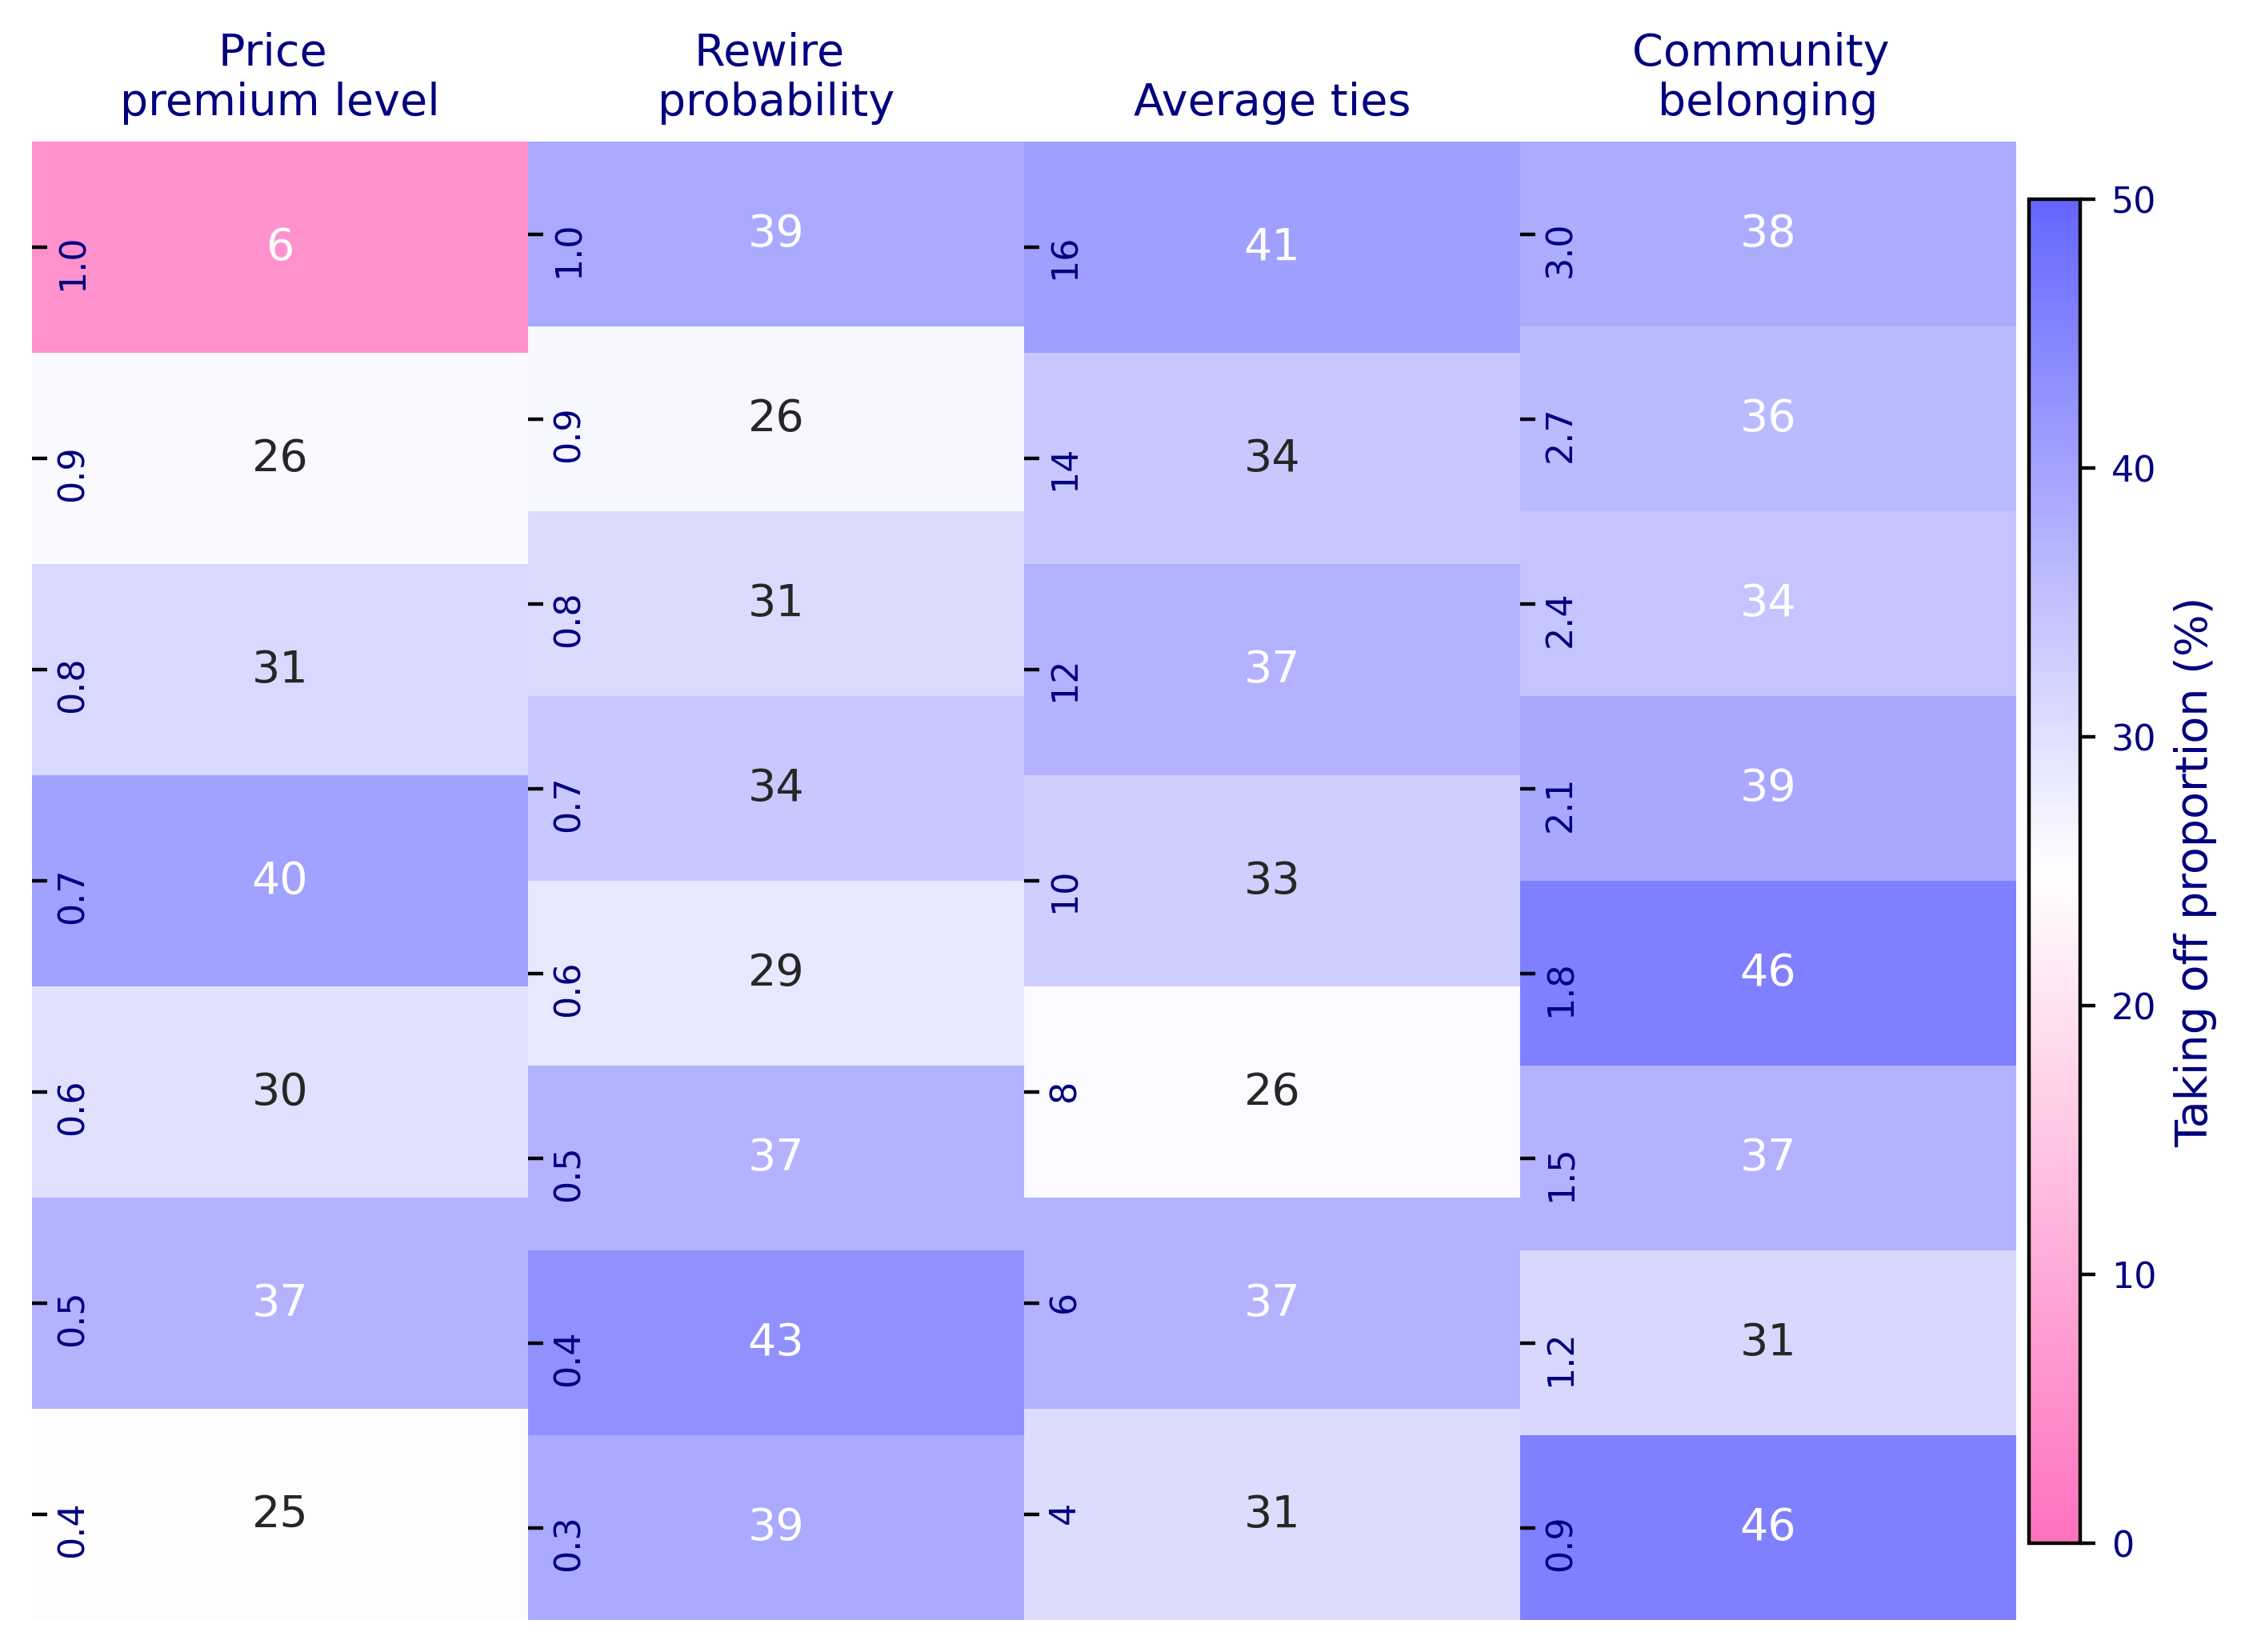

In [31]:
import seaborn as sns
price_heatmap_data1=Diffusion_attributes_price[['Price_increasement','Take_off_proportion']]
rewire_heatmap_data1=Diffusion_attributes_rewire[['Rewire_probability','Take_off_proportion']]
ties_heatmap_data1=Diffusion_attributes_ties[['Average_ties','Take_off_proportion']]
belonging_heatmap_data1=Diffusion_attributes_belonging[['Community_belonging','Take_off_proportion']]

fig,axes=plt.subplots(1,4,figsize=(8,6),dpi=400)

vmin=0
vmax=50


sns.heatmap(price_heatmap_data1.set_index('Price_increasement'),ax=axes[0],cmap=cmap_navy_pink,alpha=0.6,annot=True,fmt='.0f',cbar=False,vmin=vmin,vmax=vmax)
sns.heatmap(rewire_heatmap_data1.set_index('Rewire_probability'),ax=axes[1],cmap=cmap_navy_pink,alpha=0.6,annot=True,fmt='.0f',cbar=False,vmin=vmin,vmax=vmax)
sns.heatmap(ties_heatmap_data1.set_index('Average_ties'),ax=axes[2],cmap=cmap_navy_pink,alpha=0.6,annot=True,cbar=False,fmt='.0f',vmin=vmin,vmax=vmax)
sns.heatmap(belonging_heatmap_data1.set_index('Community_belonging'),ax=axes[3],cmap=cmap_navy_pink,alpha=0.6,annot=True,fmt='.0f',cbar=False,vmin=vmin,vmax=vmax)

axes[0].set_title('Price \npremium level',fontsize=10,color='navy')
axes[1].set_title('Rewire \nprobability',fontsize=10,color='navy')
axes[2].set_title('Average ties',fontsize=10,color='navy')
axes[3].set_title('Community \nbelonging',fontsize=10,color='navy')

axes[0].set_xticks([])
axes[1].set_xticks([])
axes[2].set_xticks([])
axes[3].set_xticks([])

#axes[0].set_yticks([])
#axes[1].set_yticks([])
#axes[2].set_yticks([])
#axes[3].set_yticks([])

axes[0].tick_params(axis='y',labelsize=8,labelcolor='navy',direction='in',pad=-13)
#axes[0].yaxis.set_ticks_position('right')
axes[1].tick_params(axis='y',labelsize=8,labelcolor='navy',direction='in',pad=-13)
#axes[1].yaxis.set_ticks_position('right')
axes[2].tick_params(axis='y',labelsize=8,labelcolor='navy',direction='in',pad=-13)
#axes[2].yaxis.set_ticks_position('right')
axes[3].tick_params(axis='y',labelsize=8,labelcolor='navy',direction='in',pad=-13)
#axes[3].yaxis.set_ticks_position('right')

axes[0].set_ylabel("")
axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[3].set_ylabel("")

sm=plt.cm.ScalarMappable(cmap=cmap_navy_pink,norm=plt.Normalize(vmin=vmin,vmax=vmax))
sm.set_array([])

cbar_ax=fig.add_axes([0.905,0.15,0.02,0.7])
cbar=plt.colorbar(sm,ax=axes,alpha=0.6,cax=cbar_ax)
cbar.set_label('Taking off proportion (%)',fontsize=10,color='navy')
cbar.set_ticks([0,10,20,30,40,50])
cbar.ax.tick_params(labelsize=8,labelcolor='navy')
cbar.ax.invert_xaxis()

plt.subplots_adjust(wspace=0.0)
plt.savefig('Taking_off_proportion.jpg')
plt.show()

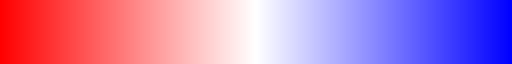

In [33]:
colors=["#FF0000","#FFFFFF","#0000FF"]
cmap_red_blue=mcolors.LinearSegmentedColormap.from_list("red_white_blue",colors)
cmap_red_blue

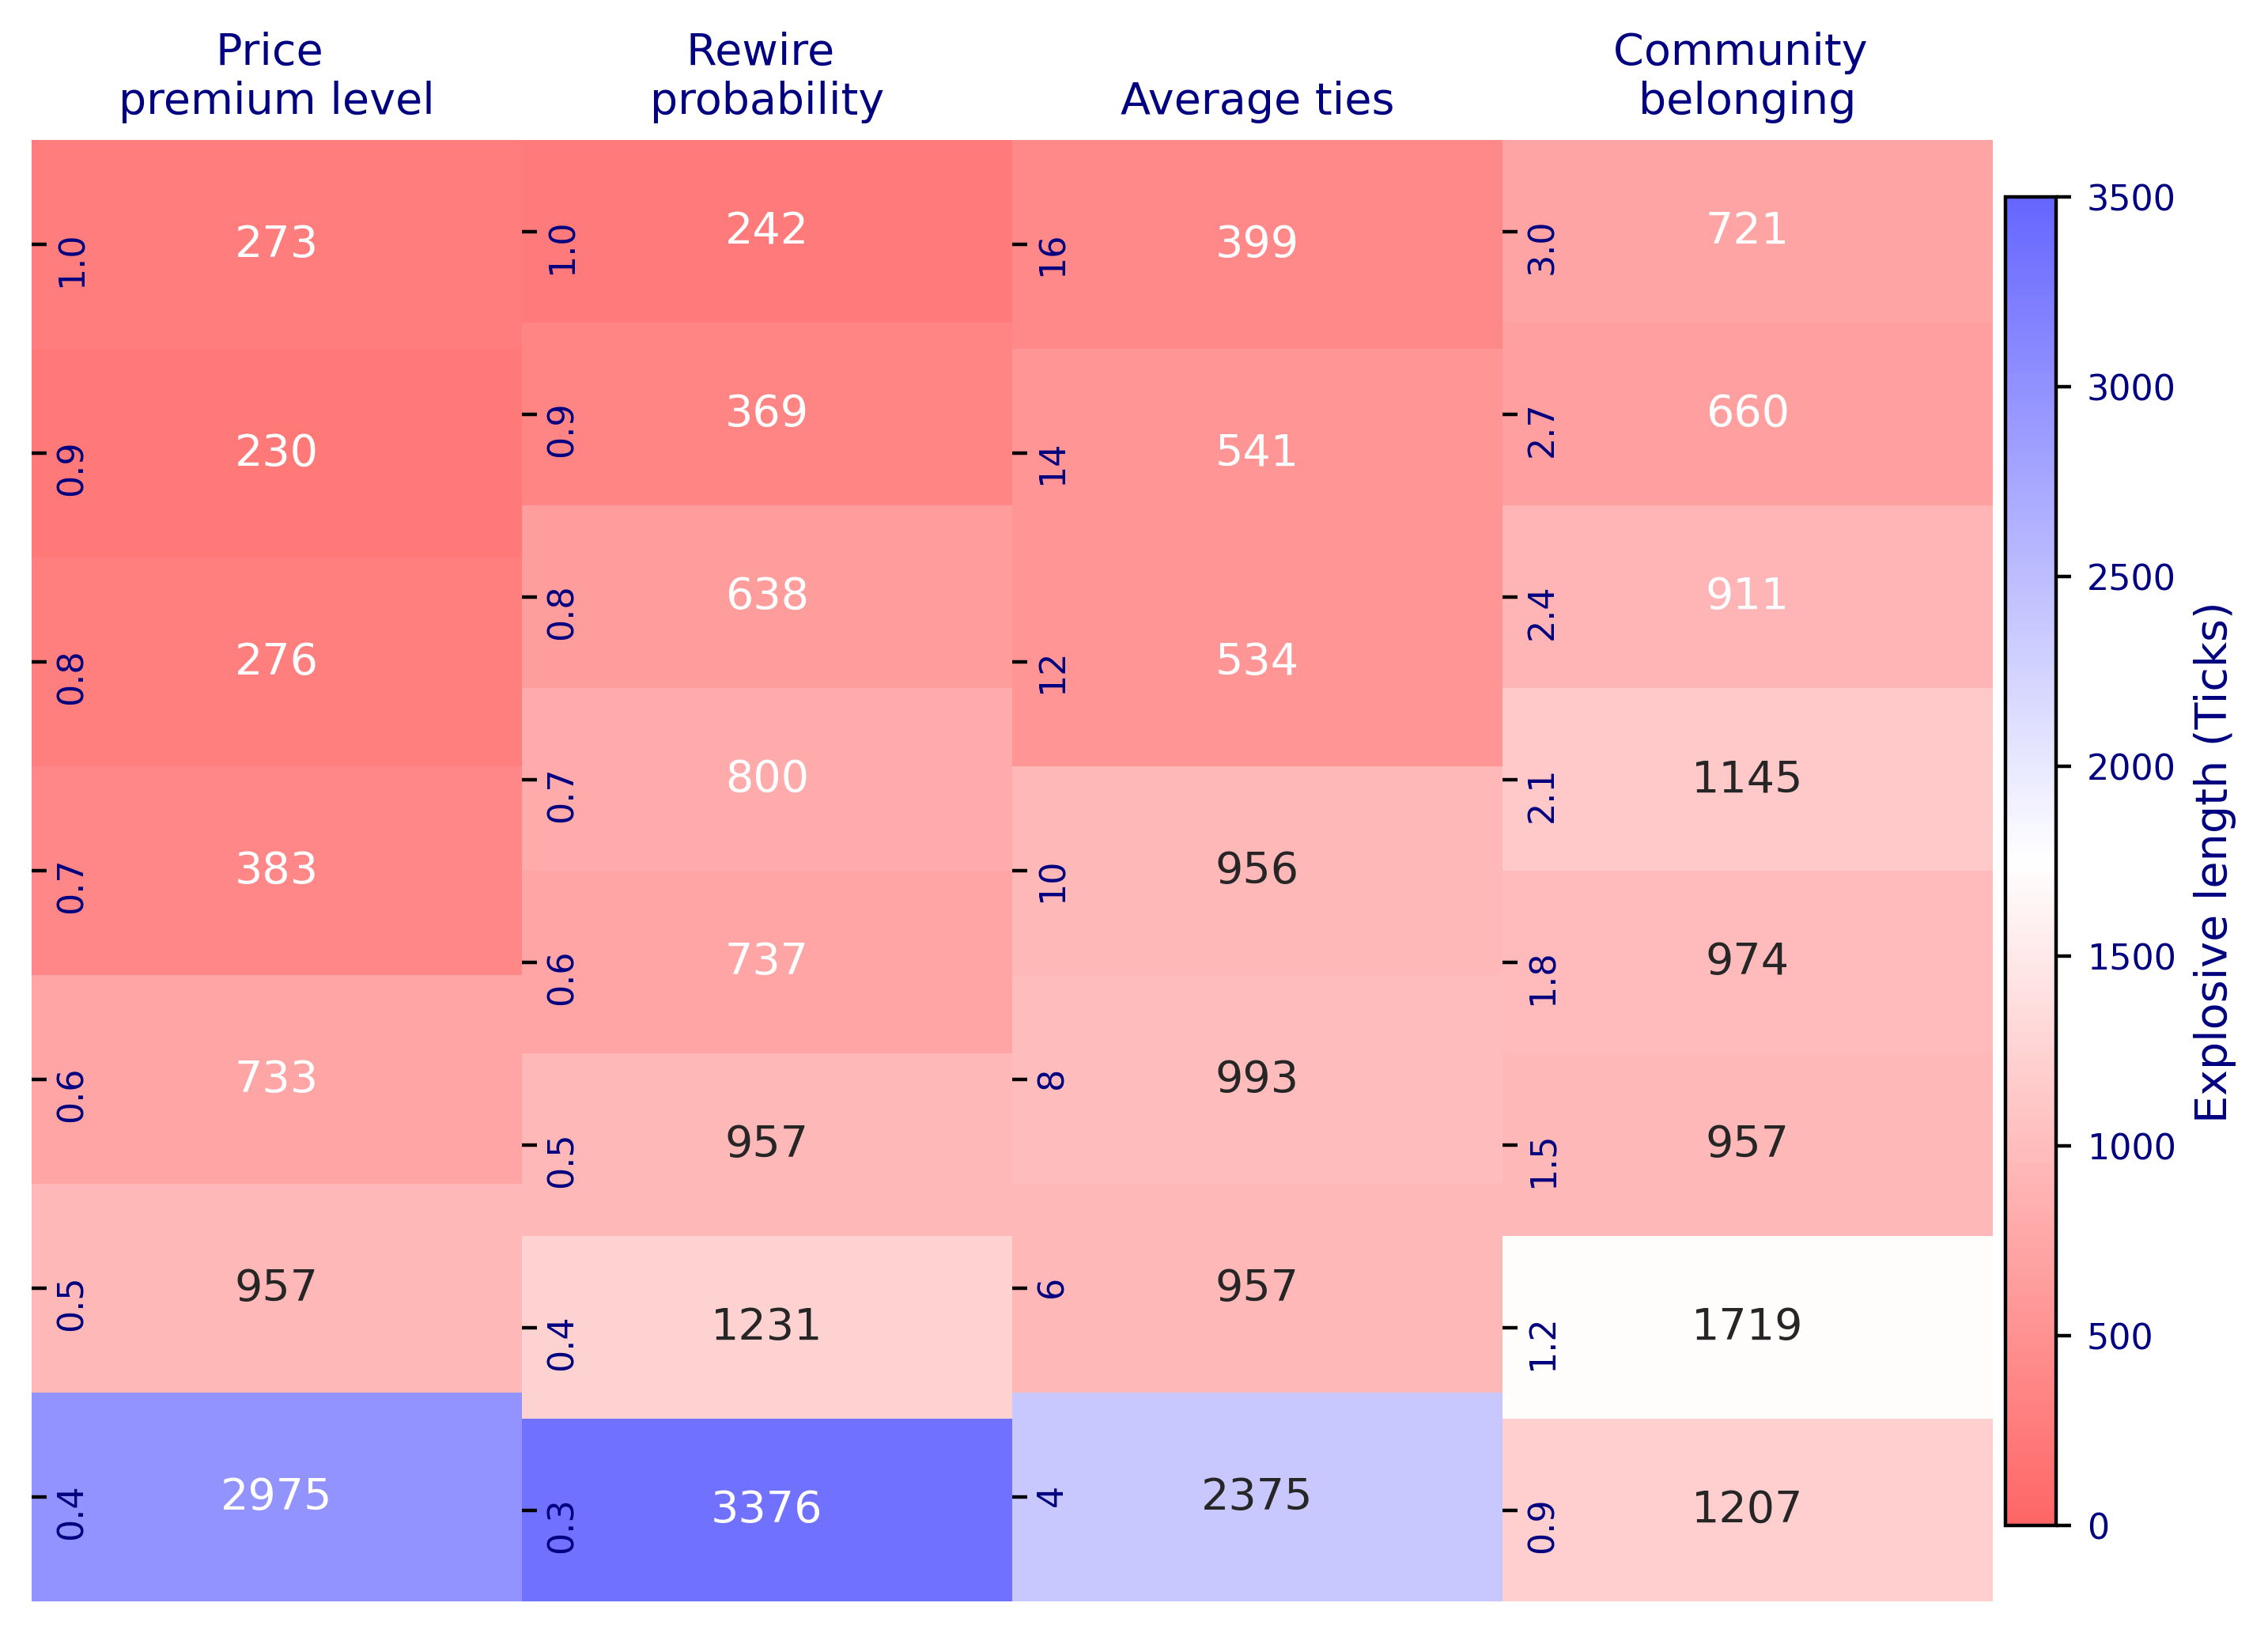

In [35]:
import seaborn as sns
price_heatmap_data2=Diffusion_attributes_price[['Price_increasement','Explosive_length']]
rewire_heatmap_data2=Diffusion_attributes_rewire[['Rewire_probability','Explosive_length']]
ties_heatmap_data2=Diffusion_attributes_ties[['Average_ties','Explosive_length']]
belonging_heatmap_data2=Diffusion_attributes_belonging[['Community_belonging','Explosive_length']]

fig,axes=plt.subplots(1,4,figsize=(8,6),dpi=400)

vmin=0
vmax=3500

sns.heatmap(price_heatmap_data2.set_index('Price_increasement'),ax=axes[0],cmap=cmap_red_blue,annot=True,alpha=0.6,fmt='.0f',cbar=False,vmin=vmin,vmax=vmax)
sns.heatmap(rewire_heatmap_data2.set_index('Rewire_probability'),ax=axes[1],cmap=cmap_red_blue,annot=True,alpha=0.6,fmt='.0f',cbar=False,vmin=vmin,vmax=vmax)
sns.heatmap(ties_heatmap_data2.set_index('Average_ties'),ax=axes[2],cmap=cmap_red_blue,annot=True,cbar=False,alpha=0.6,fmt='.0f',vmin=vmin,vmax=vmax)
sns.heatmap(belonging_heatmap_data2.set_index('Community_belonging'),ax=axes[3],cmap=cmap_red_blue,annot=True,alpha=0.6,fmt='.0f',cbar=False,vmin=vmin,vmax=vmax)

axes[0].set_title('Price \npremium level',fontsize=10,color='navy')
axes[1].set_title('Rewire \nprobability',fontsize=10,color='navy')
axes[2].set_title('Average ties',fontsize=10,color='navy')
axes[3].set_title('Community \nbelonging',fontsize=10,color='navy')

axes[0].set_xticks([])
axes[1].set_xticks([])
axes[2].set_xticks([])
axes[3].set_xticks([])

#axes[0].set_yticks([])
#axes[1].set_yticks([])
#axes[2].set_yticks([])
#axes[3].set_yticks([])

axes[0].tick_params(axis='y',labelsize=8,labelcolor='navy',direction='in',pad=-13)
#axes[0].yaxis.set_ticks_position('right')
axes[1].tick_params(axis='y',labelsize=8,labelcolor='navy',direction='in',pad=-13)
#axes[1].yaxis.set_ticks_position('right')
axes[2].tick_params(axis='y',labelsize=8,labelcolor='navy',direction='in',pad=-13)
#axes[2].yaxis.set_ticks_position('right')
axes[3].tick_params(axis='y',labelsize=8,labelcolor='navy',direction='in',pad=-13)
#axes[3].yaxis.set_ticks_position('right')

axes[0].set_ylabel("")
axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[3].set_ylabel("")

sm=plt.cm.ScalarMappable(cmap=cmap_red_blue,norm=plt.Normalize(vmin=vmin,vmax=vmax))
sm.set_array([])

cbar_ax=fig.add_axes([0.905,0.15,0.02,0.7])
cbar=plt.colorbar(sm,ax=axes,alpha=0.6,cax=cbar_ax)
cbar.set_label('Explosive length (Ticks)',fontsize=10,color='navy')
cbar.set_ticks([0,500,1000,1500,2000,2500,3000,3500])
cbar.ax.tick_params(labelsize=8,labelcolor='navy')
cbar.ax.invert_xaxis()

plt.subplots_adjust(wspace=0.0)
plt.savefig('explorsive length.jpg')
plt.show()

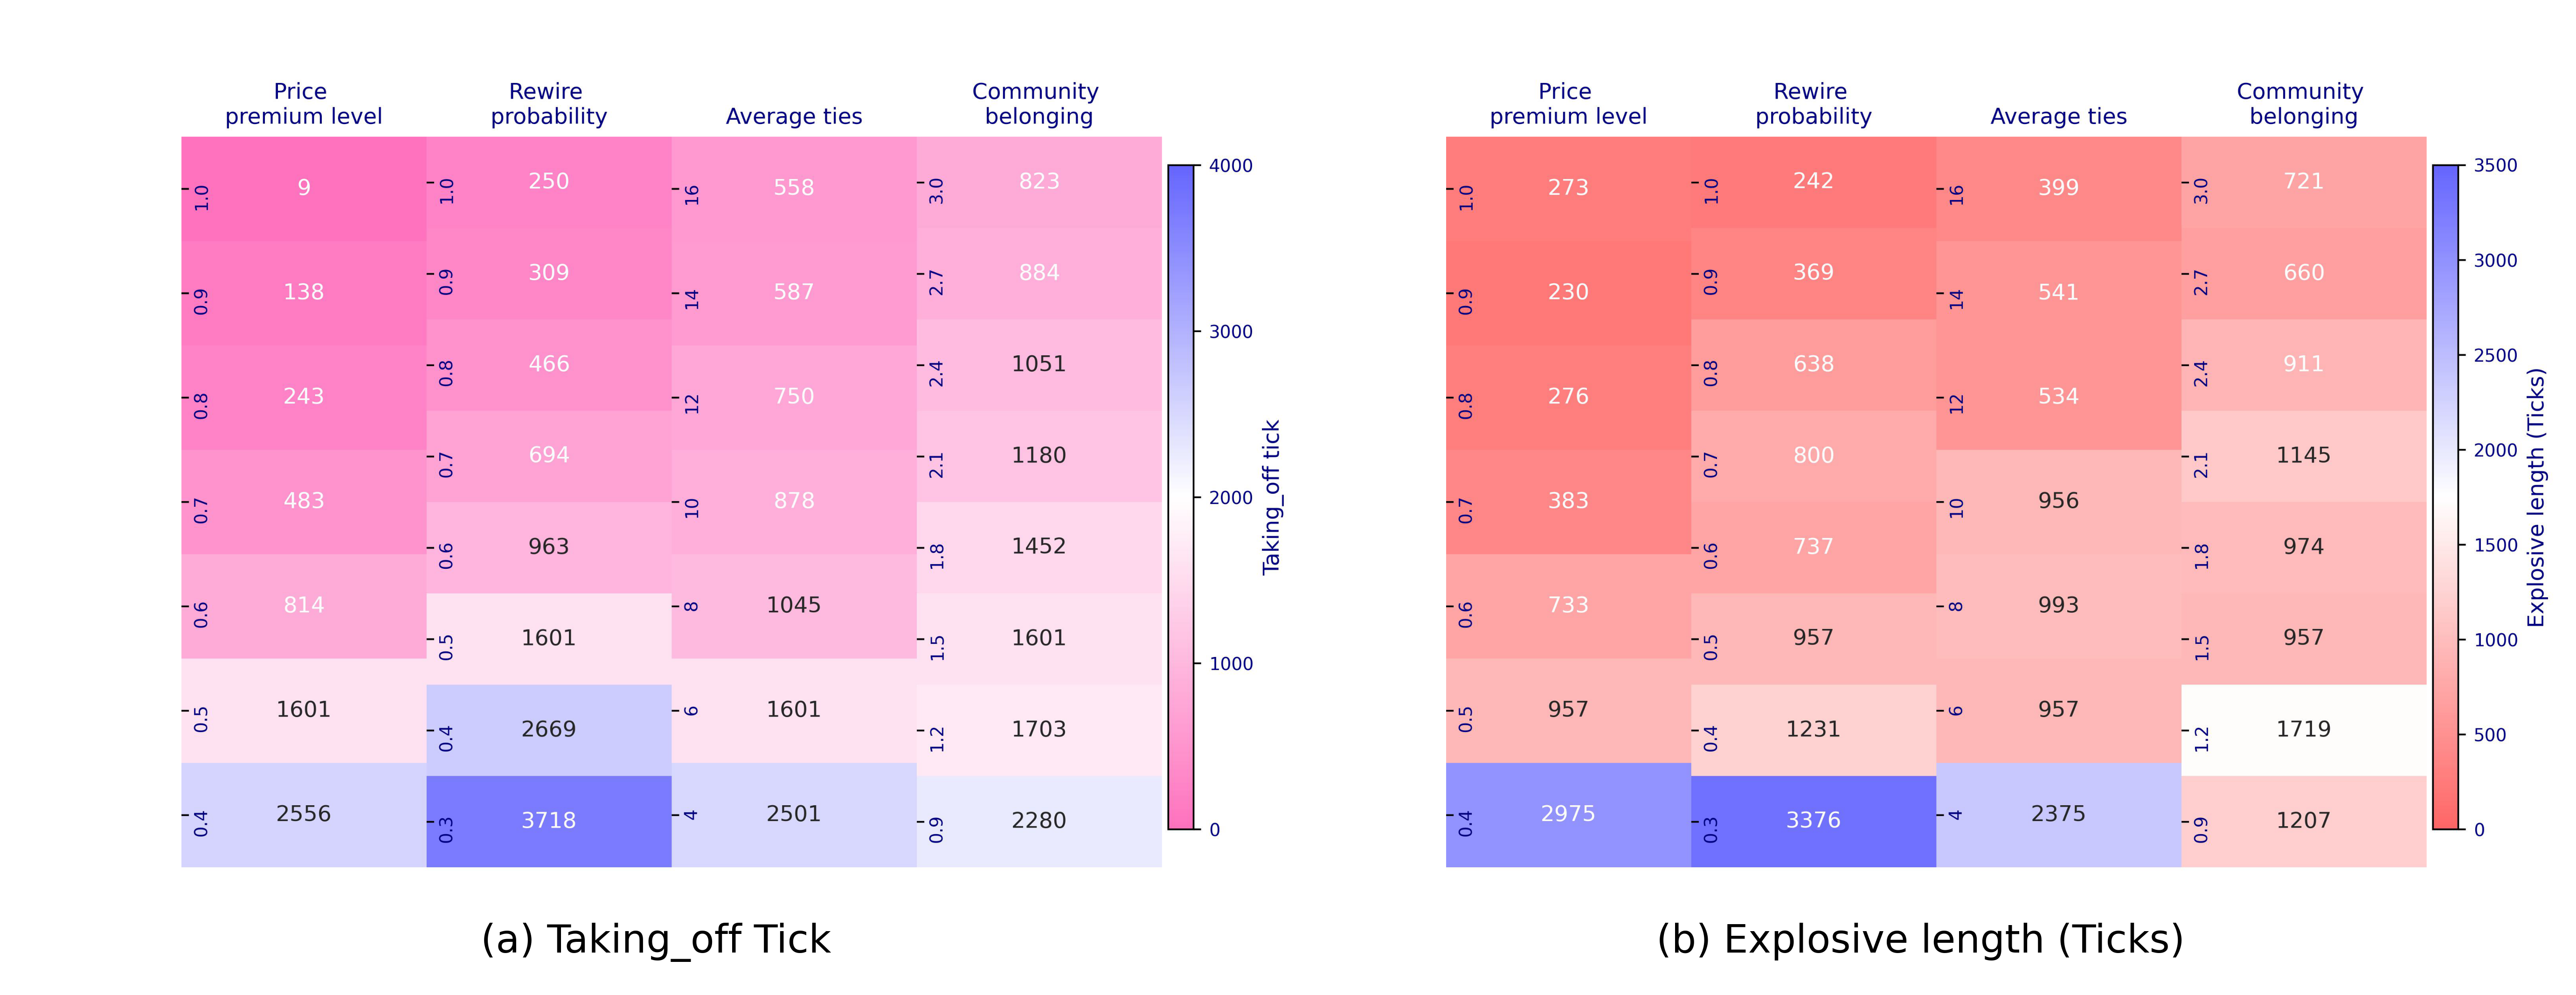

In [37]:
import matplotlib.image as mpimg

fig, ax = plt.subplots(1,2,figsize=(14, 6),dpi=500)

img2=mpimg.imread('Taking_off_tick.jpg')
img1=mpimg.imread('explorsive length.jpg')

ax[1].imshow(img1)
ax[1].axis('off')
ax[1].set_title('(b) Explosive length (Ticks)', fontsize=12, y=0)

ax[0].imshow(img2)
ax[0].axis('off')
ax[0].set_title('(a) Taking_off Tick', fontsize=12, y=0)

plt.subplots_adjust(wspace=0)
plt.savefig('explorsive length and taking off tick.jpg')
plt.show()


In [153]:
Diffusion_attributes.to_excel('Diffusion_attributes.xlsx',index=False)